<a href="https://colab.research.google.com/github/siriwatsc-debug/ProjectDADS5001/blob/main/DADS5001_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# install the required packages for map
!pip install cartopy folium
!pip install openpyxl
!pip install Pillow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 99.2 MB/s eta 0:00:00


In [2]:
# Subject : DADS5001 - Tools and Programing
# Project : Pandas/Numpy
# Topic : EStudy the factors to occur the eartquake
# Team members : Siriwat/Sahaphum/Kridsada

# Analysis for insight and Story Telling
#: Global --> Local (Thailand) --> Risk Area --> Impact/Damage
# Overall explanation                                       Dong - DONE
# Thai sensors station                                      Dong - DONE
# Plates movements : Indian plate affected to Thailand      Dong - DONE


# Questions
# 1.แผ่นดินไหวเกิดขึ้นบ่อยที่สุดในช่วงปี/เดือน ?                        DROP
# 2.จังหวัดหรือภูมิภาคใดของไทยที่มีแผ่นดินไหวเกิดขึ้นบ่อยที่สุด?
#   2.1 Overall  by Region                                  Tiger : Bar x1 Chart - DONE
#   2.2 By Region and Magnitude                             Dong  : Map x5 - DONE
#   2.3 By Province : Top x5                                Tiger : Bar - DONE
#
#   By Depth / Phase ?                                      Tiger
# 3.ค่าขนาดแผ่นดินไหว (Magnitude) เฉลีย่ในแต่ละภูมิภาคเป็นอย่างไร? --> Should be Max
#   3.1 Average max                                         Tiger
# 4.ข้อมูลแผ่นดินไหวของไทยเมื่อเทียบกับประเทศในภูมิภาคเอเชียตะวันออกเฉียงใต้เป็นอย่างไร
#   4.1 Comparison : Frequency/Event/Mag by Country         Tiger/Dong - DONE
# 5.Disaster impact of EQ in thailand เป็นอย่างไร             Film

# Add
# : Risk Area (Top 5 province) and Non-Risk Area (Top 5 province), Mag occured > 0 and > 5
# : Depth and Phase related to risk area ? High : Depth / Phase , High Risk ?                 DROP ?
# : Station and Max count of --> From Paper : Sensor Orientation of the TMD Seismic Network (Thailand) from P-Wave Particle Motions (2009-2022)
#     https://earthquake.tmd.go.th/documents/file/Supplementary_Info_PatinyaPornsopin2022.pdf

# Next plan : Prediction but Data is huge and require Geo Knowledge on EQ parameters.

import sys
import pandas as pd
import numpy as np
import IPython
from IPython.display import display, Markdown, Latex, HTML, IFrame, JSON, Code, Image, YouTubeVideo, clear_output

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from PIL import Image
from google.colab import drive

from pathlib import WindowsPath
import matplotlib.patches as patches

from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# Load data by Google Drive - Obsoleted and replaced with Github
#drive.mount('/content/drive')
#df_eq = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/DATA_Earthquake_Draft1.xlsx') # --> Old data
#df_eq = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/ProjectPandas/DATA_Earthquake_Draft1_Cleaned.xlsx')
#df_pl = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/ActiveFault-Plates.xlsx', sheet_name="73 sensors EQ")
#df_dis = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/ProjectPandas/disaster_extracted.xlsx')
#df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/all-event.xlsx')




In [3]:
# Load datasets from Github :

url1 = "https://github.com/siriwatsc-debug/ProjectDADS5001/raw/main/DATA_Earthquake_Draft1_Cleaned.xlsx"
url2 = "https://github.com/siriwatsc-debug/ProjectDADS5001/raw/main/ActiveFault-Plates.xlsx"
url3 = "https://github.com/siriwatsc-debug/ProjectDADS5001/raw/main/disaster_extracted.xlsx"
#url4 = "https://github.com/siriwatsc-debug/ProjectDADS5001/raw/main/all-event.xlsx"
df_eq = pd.read_excel(url1 ,engine="openpyxl")
df_pl = pd.read_excel(url2 , sheet_name="73 sensors EQ",engine="openpyxl")
df_dis = pd.read_excel(url3 ,engine="openpyxl")
#df = pd.read_excel(url4 ,engine="openpyxl")


In [4]:
# Load data by Google Drive - Obsoleted and replaced with Github

drive.mount('/content/drive')
#df_eq = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/DATA_Earthquake_Draft1.xlsx') # --> Old data
df_eq = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/ProjectPandas/DATA_Earthquake_Draft1_Cleaned.xlsx')
df_pl = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/ActiveFault-Plates.xlsx', sheet_name="73 sensors EQ")
df_dis = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/ProjectPandas/disaster_extracted.xlsx')
#df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/all-event.xlsx')



Mounted at /content/drive


In [5]:
# Check data frame on each datasets
df_eq.head()            # Earth Quake data
df_pl.head()            # Active plates data
df_dis.head()           # Disaster and Impact date
#df.head()               # Original data --> Will terminate


,DisNo.,Classification Key,Disaster Type,Disaster Subtype,Country,Subregion,Region,Location,Associated Types,Magnitude,...,No. Homeless,Total Affected,Reconstruction Costs ('000 US$),"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",Entry Date,Last Update
0,2000-0023-BGD,nat-geo-ear-gro,Earthquake,Ground movement,Bangladesh,Southern Asia,Asia,"Maheshkhali area (Cox's Bazar district, Chitta...",NaN,4.3,...,NaN,1000.0,NaN,NaN,NaN,NaN,NaN,NaN,2011-04-07,2023-09-25
1,2000-0033-CHN,nat-geo-ear-gro,Earthquake,Ground movement,China,Eastern Asia,Asia,"Yongren Xian, Yao'an Xian, Nanhua Xian, Dayao ...",NaN,5.9,...,92479.0,1855007.0,NaN,NaN,NaN,NaN,73500.0,133892.0,2003-09-09,2023-09-25
2,2000-0036-CHN,nat-geo-ear-gro,Earthquake,Ground movement,China,Eastern Asia,Asia,"Mile Xian area (Honghe Hani and Yi district, Y...",NaN,4.9,...,NaN,10302.0,NaN,NaN,NaN,NaN,483.0,880.0,2010-03-04,2023-09-25
3,2000-0041-CHN,nat-geo-ear-gro,Earthquake,Ground movement,China,Eastern Asia,Asia,"Xiuyan Manzu Zizhixian area (Anshan district, ...",NaN,5.1,...,18000.0,62030.0,NaN,NaN,NaN,NaN,NaN,NaN,2003-09-09,2023-09-25
4,2000-0051-IRN,nat-geo-ear-gro,Earthquake,Ground movement,Iran (Islamic Republic of),Southern Asia,Asia,"Kashmar, Bardeskan districts (Khorasan)",NaN,5.3,...,500.0,2015.0,NaN,NaN,NaN,NaN,NaN,NaN,2014-03-07,2023-09-25


In [9]:
# Equak Data : Lat,Long,Mag,Dep,Phase, Date, Time, Area (District,Province, Country)
# Original data
df_eq.info()

# Rename existing columns ID : Data Frame EarthQuake
df_eq = df_eq.rename(columns={'No.':'no', 'REF. ID':'refid', 'DATE-TIME UTC':'dtutc','DATE_THAI':'date','YEAR':'year', 'MONTH' : 'month', 'DAY' : 'day',
                              'TIME THAI':'time', 'LAT.':'lat', 'LONG.':'long','MAG.':'mag',
                              'DEPTH.':'depth', 'PHASE.':'phase', 'REGION_NANE_THAI':'region_th','SUB_DISTINCT':'subdistrict', 'DISTINCT':'district',
                              'PROVINCE':'province', 'COUNTRY':'country', 'REGION':'region'}) # default: inplace=False

df_eq.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14986 entries, 0 to 14985
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   no               14986 non-null  int64         
 1   refid            14986 non-null  object        
 2   dtutc            14986 non-null  object        
 3   date             14986 non-null  datetime64[ns]
 4   year             14986 non-null  datetime64[ns]
 5   month            14986 non-null  int64         
 6   day              14986 non-null  int64         
 7   time             14986 non-null  object        
 8   lat              14986 non-null  float64       
 9   long             14986 non-null  float64       
 10  mag              14986 non-null  float64       
 11  MAG_RANGE        14986 non-null  object        
 12  MAG_RANGE_DES    14986 non-null  object        
 13  depth            14986 non-null  float64       
 14  phase            14986 non-null  int64

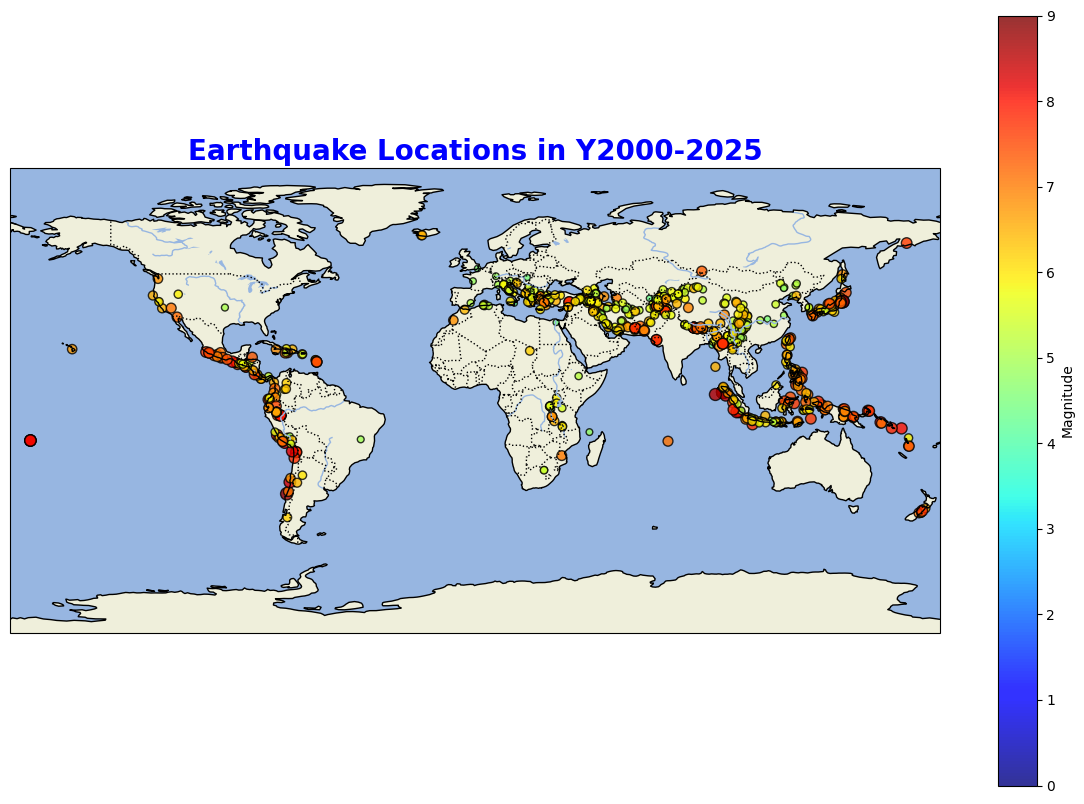

# Global : Earthquake disasters  
## <font color=Green>ที่มา :  https://www.emdat.be </font>



In [10]:
# Overall Earth Quake Global with Disaster

# Set Data Frame : Disaster
#df = df_dis
#print(df.columns)

# Rename existing columns ID
df2 = df_dis.rename(columns={'DisNo.':'DisNo', 'Classification Key':'classKey',
                             'Disaster Type':'distype','Disaster Subtype':'dissubtype',
                             'Country':'country', 'Subregion':'subreg', 'Associated Types':'assotype',
                             'Magnitude':'mag', 'Latitude':'lat', 'Longitude':'long',  'Start Year':'styear',
                             'Start Month':'stmonth',
                             'Start Day':'stday', 'End Year':'endyear','End Month':'endmonth', 'End Day':'endday',
                             'Total Deaths':'totaldeaths', 'No. Injured':'injure','No. Affected':'affected',
                             'No. Homeless':'homeless', 'Total Affected':'totalaffected',
                             'Reconstruction Costs (\'000 US$)':'recon_cost',
                             'Reconstruction Costs, Adjusted (\'000 US$)':'recon_cost_adj',
                             'Insured Damage (\'000 US$)':'insuredamage',
                             'Insured Damage, Adjusted (\'000 US$)':'insuredamage_adj',
                             'Total Damage (\'000 US$)':'totaldamage',
                             'Total Damage, Adjusted (\'000 US$)' : 'totaldamage_adj',
                             'Entry Date':'entrydate', 'Last Update':'lastupdate'}) # default: inplace=False

#df2.info()

# column: 'Latitude', 'Longitude', 'Magnitude'
lat = df2["lat"]
lon = df2["long"]
mag = df2["mag"]

# Plot map
fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add borders
#ax.add_feature(cfeature.STATES)
ax.add_feature(cfeature.LAKES)
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.RIVERS)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Set Frame to plot for Global
ax.set_extent([-180, 180, -180, 180], crs=ccrs.PlateCarree())

# plot EQ location by lat and long
sc = ax.scatter(
    lon, lat,
    c=mag, s=mag**2,   # ขนาดจุด ∝ magnitude
    cmap="jet", alpha=0.8,
    vmin=0, vmax=9.0,
    edgecolor="k", transform=ccrs.PlateCarree()
)

# colorbar
plt.colorbar(sc, ax=ax, label="Magnitude")
#plt.text(-10, -10, 'Earthquake Locations with Magnitude (2000-2025) with disaster', fontsize = 15, fontweight='bold', color='blue')
plt.title("Earthquake Locations in Y2000-2025",fontsize = 20, fontweight='bold', color='blue', loc = 'center')
plt.show()


s = """# Global : Earthquake disasters
## <font color=Green>ที่มา :  https://www.emdat.be </font>

"""

display( Markdown(s) )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# แผนที่ : รอยเลื่อนที่มีพลังในประเทศไทย 
(Map of Active Faults in Thailand)
## <font color=Green>ที่มา : wiki pedia (https://en.wikipedia.org/wiki/List_of_tectonic_plates)</font>


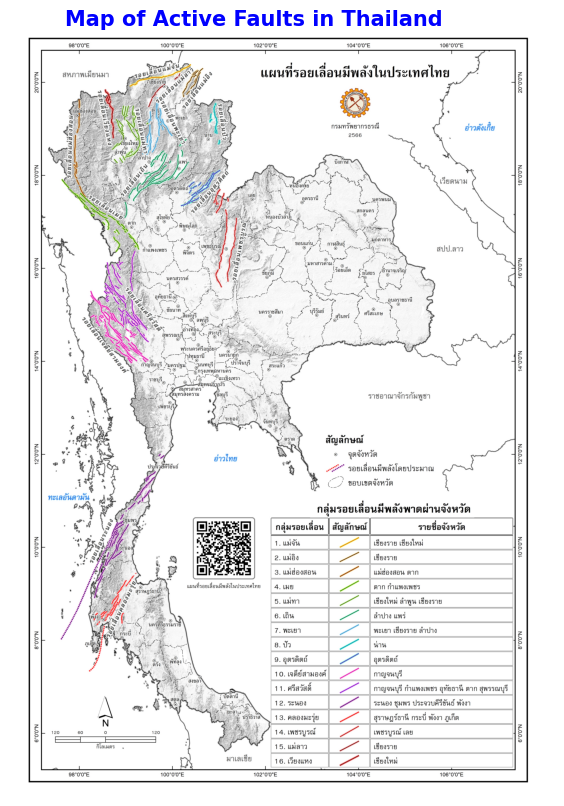

In [20]:
# Add Active Faults in Thailand

# Load data by Google Drive
drive.mount('/content/drive')
pic = '/content/drive/MyDrive/Colab Notebooks/ProjectPandas/P-5 activefault_2023_16fault_Hillshade_BookA3.jpeg'
img = Image.open(pic)

fig, ax = plt.subplots(figsize=(15 , 10))
ax.imshow(img)

#plt.figure(figsize=(15,10))
ax.axis('off')

# highlight rectangle to Thailand
x = 1420
y = 340
width = 60
height = 120
#highlight = patches.Rectangle( (x,y), width, height, linewidth=3, edgecolor='blue', facecolor='none', alpha=0.7)
#highlight = patches.Rectangle( (x,y), width, height, linewidth=2, edgecolor='red', facecolor='green', alpha=0.3)

#ax.add_patch(highlight)
ax.text(600, -10, 'Map of Active Faults in Thailand', fontsize = 15, fontweight='bold', color='blue')

s = """# แผนที่ : รอยเลื่อนที่มีพลังในประเทศไทย
(Map of Active Faults in Thailand)
## <font color=Green>ที่มา : wiki pedia (https://en.wikipedia.org/wiki/List_of_tectonic_plates)</font>
"""

display( Markdown(s) )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# แผนที่ : แผ่นเปลือกโลกหลัก 16 แผ่น 
(Map of Earth's 16 principal tectonic plates)
## <font color=Green>ที่มา : wiki pedia (https://en.wikipedia.org/wiki/List_of_tectonic_plates)</font>


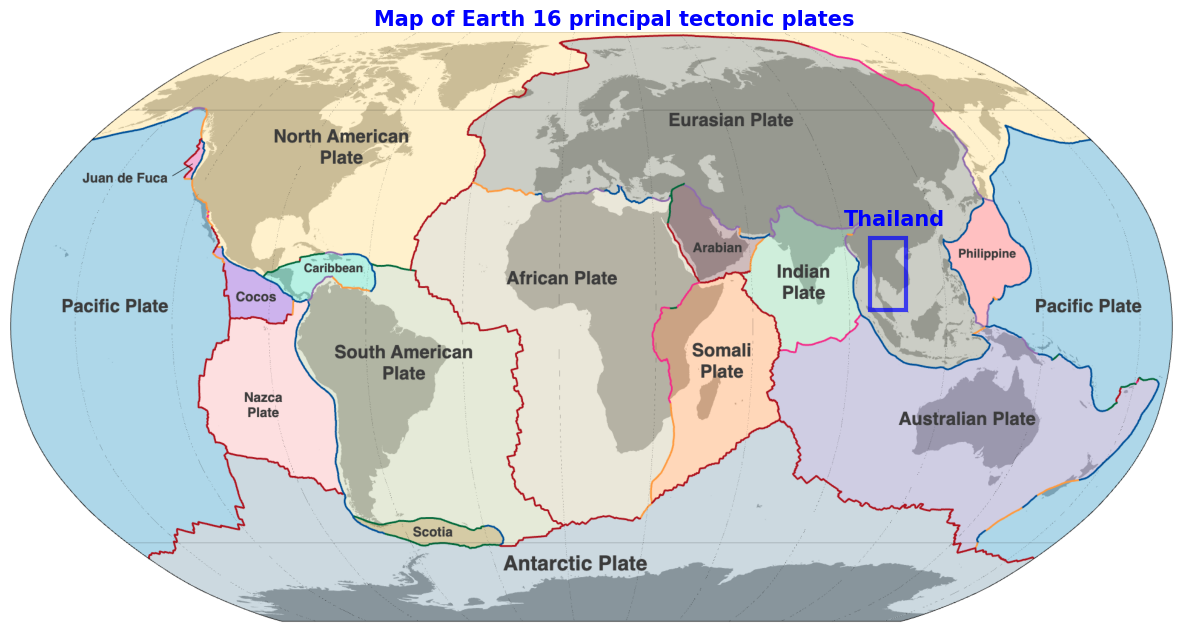

In [13]:
# Add image 16 principal plates in the world

# Load data by Google Drive
drive.mount('/content/drive')
pic = '/content/drive/MyDrive/Colab Notebooks/ProjectPandas/Wiki_Earth_plates.png'
img = Image.open(pic)

fig, ax = plt.subplots(figsize=(15 , 10))
ax.imshow(img)

#plt.figure(figsize=(15,10))
ax.axis('off')

# highlight rectangle to Thailand
x = 1420
y = 340
width = 60
height = 120
highlight = patches.Rectangle( (x,y), width, height, linewidth=3, edgecolor='blue', facecolor='none', alpha=0.7)
#highlight = patches.Rectangle( (x,y), width, height, linewidth=2, edgecolor='red', facecolor='green', alpha=0.3)

ax.add_patch(highlight)
ax.text(600, -10, 'Map of Earth 16 principal tectonic plates', fontsize = 15, fontweight='bold', color='blue')
ax.text(x+40, y-30, 'Thailand', fontsize = 15, fontweight='bold', color='blue', ha='center', va='center')

# Add Arrow
#ax.arrow(0, 100, 200, 100, head_width=10, head_length=0.1,
#         fc='red', ec='orange', linewidth=7)
#ax.text(1.25, 110, 'Increasing trend', ha='center', fontweight='bold')

s = """# แผนที่ : แผ่นเปลือกโลกหลัก 16 แผ่น
(Map of Earth's 16 principal tectonic plates)
## <font color=Green>ที่มา : wiki pedia (https://en.wikipedia.org/wiki/List_of_tectonic_plates)</font>
"""

display( Markdown(s) )

/usr/local/lib/python3.12/dist-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturale

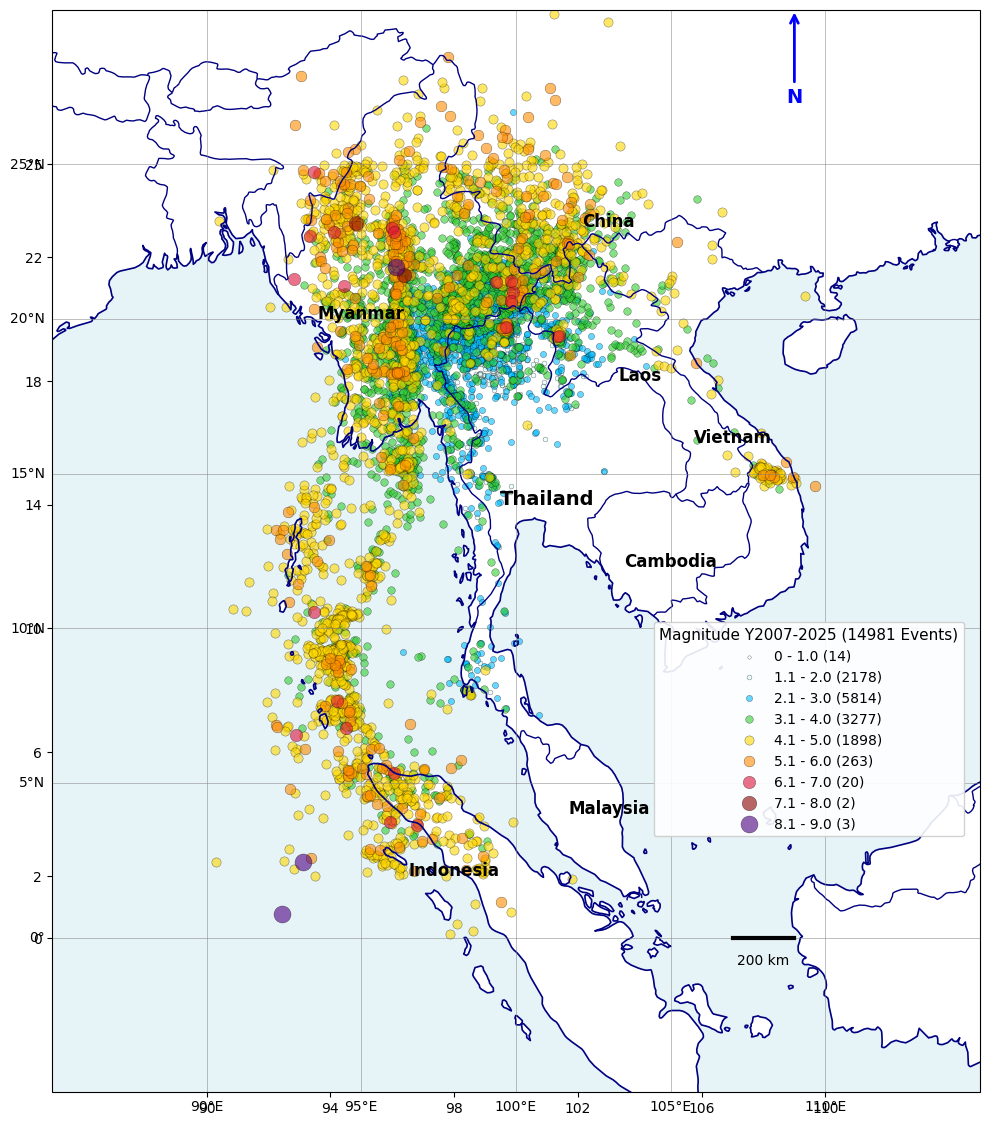

# Local : Earthquake in Thailand and nearby
## <font color=Green>ที่มา : กองเฝ้าระวังแผ่นดินไหว (https://earthquake.tmd.go.th)</font>



In [14]:
# Plot : Overall Magnitude by range VS Areas around Thailand

# Load data EQ
df = df_eq.copy()

# Pick : lat, long and magnitude
lat_all = df["lat"].values
lon_all = df["long"].values
mag_all = df["mag"].values

# Frame position in Map (SEA region)
mask = (lat_all >= 0) & (lat_all <= 30) & (lon_all >= 90) & (lon_all <= 115)
lat_filtered = lat_all[mask]
lon_filtered = lon_all[mask]
mag_filtered = mag_all[mask]

# Create Map
fig = plt.figure(figsize=(10, 15))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([85, 115, -5, 30], crs=ccrs.PlateCarree())

# Add Geo features
ax.add_feature(cfeature.COASTLINE, linewidth=1.2, color='navy')
ax.add_feature(cfeature.BORDERS, linewidth=1.0, color='navy')
ax.add_feature(cfeature.LAND, color='white', alpha=0.8)
ax.add_feature(cfeature.OCEAN, color='lightblue', alpha=0.3)

# Create colormap and size mapping
colors_map = {
    (0, 1.0):   ('white', 3),           # ขาว
    (1.1, 2.0): ('lightcyan', 6),       # ฟ้าอ่อนมาก
    (2.1, 3.0): ('deepskyblue', 10),    # ฟ้า
    (3.1, 4.0): ('limegreen', 15),      # เขียว
    (4.1, 5.0): ('gold', 22),           # ทอง
    (5.1, 6.0): ('darkorange', 30),     # ส้มเข้ม
    (6.1, 7.0): ('crimson', 40),        # แดงเข้ม
    (7.1, 8.0): ('darkred', 55),        # แดงเข้มมาก
    (8.1, 9.0): ('indigo', 75)          # น้ำเงินเข้ม
}

# Put EQ Mag in each lat and long
for (min_mag, max_mag), (color, size) in colors_map.items():
    mask_mag = (mag_filtered >= min_mag) & (mag_filtered < max_mag)
    if np.any(mask_mag):
        count = np.sum(mask_mag)
        ax.scatter(lon_filtered[mask_mag], lat_filtered[mask_mag],
                   c=color, s=size*2, alpha=0.6,
                   edgecolor='black', linewidth=0.3,
                   transform=ccrs.PlateCarree(),
                   label=f'{min_mag} - {max_mag} ({count})')

# Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
ax.set_xticks([90, 94, 98, 102, 106, 110], crs=ccrs.PlateCarree())
ax.set_yticks([0, 2, 6, 10, 14, 18, 22, 25], crs=ccrs.PlateCarree())

# Label Country
ax.text(95, 20, 'Myanmar', fontsize=12, ha='center', fontweight='bold')
ax.text(103, 23, 'China', fontsize=12, ha='center', fontweight='bold')
ax.text(104, 18, 'Laos', fontsize=12, ha='center', fontweight='bold')
ax.text(101, 14, 'Thailand', fontsize=14, ha='center', fontweight='bold')
ax.text(107, 16, 'Vietnam', fontsize=12, ha='center', fontweight='bold')
ax.text(105, 12, 'Cambodia', fontsize=12, ha='center', fontweight='bold')
ax.text(103, 4, 'Malaysia', fontsize=12, ha='center', fontweight='bold')
ax.text(98, 2, 'Indonesia', fontsize=12, ha='center', fontweight='bold')

# Legend
legend = ax.legend(title=f'Magnitude Y2007-2025 ({len(mag_filtered)} Events)',
                   loc='lower right', fontsize=10, title_fontsize=11,
                   bbox_to_anchor=(0.99, 0.23))
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.9)

# Scale bar
scale_lon = 107
scale_lat = 0
ax.plot([scale_lon, scale_lon+2], [scale_lat, scale_lat], 'k-', lw=3,
        transform=ccrs.PlateCarree())
ax.text(scale_lon+1, scale_lat-0.5, '200 km',
        ha='center', va='top', fontsize=10,
        transform=ccrs.PlateCarree())

# North arrow
ax.annotate('N', xy=(109, 30), xytext=(109, 27),
            arrowprops=dict(arrowstyle='->', lw=2, color ='blue'),
            fontsize=14, ha='center', fontweight='bold', color ='blue',
            transform=ccrs.PlateCarree())

plt.tight_layout()
plt.show()

s = """# Local : Earthquake in Thailand and nearby
## <font color=Green>ที่มา : กองเฝ้าระวังแผ่นดินไหว (https://earthquake.tmd.go.th)</font>

"""

display( Markdown(s) )

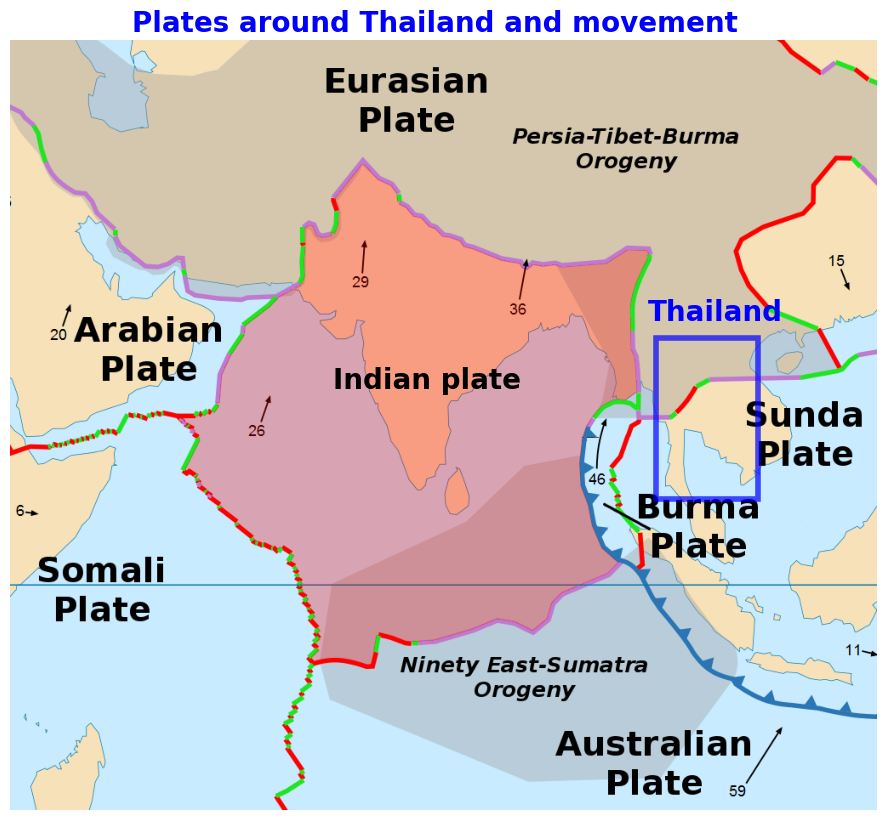

# แผ่นเปลือกโลกบริเวณประเทศไทย และ ข้อมูลการเคลื่อนตัว 
## <font color=Green>ที่มา : wiki pedia (https://en.wikipedia.org/wiki/Indian_plate)</font>
### ขนาดพื้นที่ และ การเคลื่อนตัว 
- Approximate area	11,900,000 km2 (4,600,000 sq mi)
- Movement:	North-east
- Speed1	26–36 mm/a (1.0–1.4 in/year)



In [12]:
# Scope to Thailand

pic = '/content/drive/MyDrive/Colab Notebooks/ProjectPandas/IndianPlate.png'
img = Image.open(pic)

fig, ax = plt.subplots(figsize=(15 , 10))
ax.imshow(img)

#plt.figure(figsize=(15,10))
ax.axis('off')

# highlight rectangle to Thailand
x = 760
y = 350
width = 120
height = 190
highlight = patches.Rectangle( (x,y), width, height, linewidth=4, edgecolor='blue', facecolor='none', alpha=0.7)
#highlight = patches.Rectangle( (x,y), width, height, linewidth=2, edgecolor='red', facecolor='green', alpha=0.3)

ax.add_patch(highlight)
ax.text(x+70, y-30, 'Thailand', fontsize = 20, fontweight='bold', color='blue', ha='center', va='center')

# Add Indian plate
ax.text(x-270, y+50, 'Indian plate', fontsize = 20, fontweight='bold', color='black', ha='center', va='center')
ax.text(500, -20, 'Plates around Thailand and movement', fontsize = 20, fontweight='bold', color='blue', ha='center', va='center')
plt.show()


# Add explanation for Indian plate movement
s = """# แผ่นเปลือกโลกบริเวณประเทศไทย และ ข้อมูลการเคลื่อนตัว
## <font color=Green>ที่มา : wiki pedia (https://en.wikipedia.org/wiki/Indian_plate)</font>
### ขนาดพื้นที่ และ การเคลื่อนตัว
- Approximate area	11,900,000 km2 (4,600,000 sq mi)
- Movement:	North-east
- Speed1	26–36 mm/a (1.0–1.4 in/year)

"""
display( Markdown(s) )


In [ ]:
# Plot : top 5 provinces occured EQ

import pandas as pd, numpy as np, matplotlib.pyplot as plt, os

df = df_eq.copy()


# --- tidy column names & detect columns ---
df.columns = [c.strip() for c in df.columns]
col_map = {c.lower(): c for c in df.columns}
date_col = next((c for c in df.columns if 'date' in c.lower() and 'thai' not in c.lower()), None)
lat_col = col_map.get('lat.') or col_map.get('lat')
lon_col = col_map.get('long.') or col_map.get('long')
prov_col = col_map.get('province')
mag_col = col_map.get('mag.') or col_map.get('mag')
country_col = col_map.get('country')

# --- parse date and extract year ---
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
df['YEAR2'] = df[date_col].dt.year

# --- normalization ---
df[prov_col] = df[prov_col].astype(str).str.strip()
df[country_col] = df[country_col].astype(str).str.strip()
df[lat_col] = pd.to_numeric(df[lat_col], errors='coerce')
df[lon_col] = pd.to_numeric(df[lon_col], errors='coerce')

# --- filter rows: COUNTRY contains 'Thailand' (to catch border labels) and YEAR between 2007-2025 ---
mask_th = df[country_col].str.contains('Thailand', na=False) & df['YEAR2'].between(2007, 2025)
df_th = df[mask_th].copy()

# --- counts per province (2007-2025) ---
counts_prov = df_th[prov_col].value_counts().rename_axis('province').reset_index(name='count')
counts_prov = counts_prov.sort_values('count', ascending=False)
counts_prov['province_norm'] = counts_prov['province'].str.title().str.strip()

# --- standard province list (Thai provinces, English names) ---
thai_provinces = [
"Bangkok","Samut Prakan","Nonthaburi","Pathum Thani","Phra Nakhon Si Ayutthaya","Ang Thong","Lop Buri","Sing Buri","Chai Nat",
"Saraburi","Nakhon Nayok","Sukhothai","Phitsanulok","Phetchabun","Kamphaeng Phet","Tak","Uthai Thani","Nakhon Sawan","Uttaradit","Phrae",
"Nan","Lamphun","Lampang","Mae Hong Son","Chiang Mai","Chiang Rai","Phayao","Nakhon Ratchasima","Buri Ram","Surin","Si Sa Ket","Ubon Ratchathani",
"Chaiyaphum","Khon Kaen","Maha Sarakham","Roi Et","Kalasin","Sakon Nakhon","Nakhon Phanom","Mukdahan","Yasothon","Nong Khai","Bueng Kan","Loei",
"Nong Bua Lam Phu","Prachin Buri","Chachoengsao","Chon Buri","Rayong","Trat","Chanthaburi","Prachuap Khiri Khan","Ratchaburi","Kanchanaburi",
"Suphan Buri","Samut Songkhram","Samut Sakhon","Nakhon Pathom","Phetchaburi","Phang Nga","Phuket","Krabi",
"Surat Thani","Nakhon Si Thammarat","Phatthalung","Songkhla","Satun","Trang","Pattani","Yala","Narathiwat",
"Amnat Charoen","Chumphon","Phichit","Ranong","Sa Kaeo","Udon Thani"
]
thai_provinces = list(dict.fromkeys([p.title() for p in thai_provinces]))

# --- observed / zero-event provinces ---
observed = set(counts_prov['province_norm'].unique())
all_provs = set([p.title() for p in thai_provinces])
zero_event_provs = sorted(list(all_provs - observed))

# --- top5 ---
top5 = counts_prov.head(5).copy()
top5['province_norm'] = top5['province'].str.title().str.strip()

# --- show & save outputs ---
print("Total Thailand events (2007-2025):", len(df_th))
print("Top 5 provinces:")
print(top5[['province','count']])
print("Number of zero-event provinces:", len(zero_event_provs))

outdir = "/mnt/data/earthquake_analysis_outputs"
os.makedirs(outdir, exist_ok=True)
counts_prov.to_csv(os.path.join(outdir, "counts_by_province_2007_2025.csv"), index=False)
top5.to_csv(os.path.join(outdir, "top5_provinces.csv"), index=False)
pd.DataFrame({'province': zero_event_provs}).to_csv(os.path.join(outdir, "zero_event_provinces.csv"), index=False)

# --- Plot: horizontal bar heatmap-like ---
prov_list = sorted(list(all_provs))
counts_map = {row['province_norm']: int(row['count']) for _,row in counts_prov.iterrows()}
counts_all = [counts_map.get(p, 0) for p in prov_list]
print(prov_list)
print(counts_all)

fig, ax = plt.subplots(figsize=(10,14))
y_pos = np.arange(len(prov_list))
bars = ax.barh(y_pos, counts_all)
ax.set_yticks(y_pos)
ax.set_yticklabels(prov_list, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Number of Earthquakes (2007-2025)')
ax.set_title('Earthquake Frequency per Province (Thailand) - 2007-2025')
cmax = max(counts_all) if counts_all else 1
for i, b in enumerate(bars):
    b.set_facecolor(plt.cm.viridis(counts_all[i]/cmax if cmax>0 else 0))
plt.tight_layout()
plt.show()

# --- Simple scatter map (lon/lat) and highlight top5 centroids ---
centroids = df_th.groupby(prov_col).agg({lat_col:'mean', lon_col:'mean'}).reset_index()
centroids['province_norm'] = centroids[prov_col].str.title().str.strip()
centroids = centroids.merge(counts_prov[['province_norm','count']], on='province_norm', how='left').fillna(0)

plt.figure(figsize=(8,10))
if len(df_th)>0:
    plt.scatter(df_th[lon_col], df_th[lat_col], s=6, alpha=0.4, label='events')
for _, row in centroids.iterrows():
    prov = row['province_norm']
    if prov in top5['province_norm'].values:
        plt.scatter(row[lon_col], row[lat_col], s=200, marker='*', color='red', zorder=5)
        plt.text(row[lon_col]+0.15, row[lat_col]+0.15, prov, fontsize=9, weight='bold')
    else:
        plt.scatter(row[lon_col], row[lat_col], s=40, marker='o', color='blue', alpha=0.6)
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.title('Thailand earthquake events and province centroids (top5 highlighted)')
plt.show()


In [ ]:
# Add Plate movement : Eurasia and Indian

pic = '/content/drive/MyDrive/Colab Notebooks/ProjectPandas/Thai_Fault_EU_Indian_plate.png'
img = Image.open(pic)

fig, ax = plt.subplots(figsize=(15 , 10))
ax.imshow(img)
ax.axis('off')
ax.text(500, -20, 'Indian plate movement #2', fontsize = 20, fontweight='bold', color='blue', ha='center', va='center')

# highlight rectangle to Thailand
x = 450
y = 400
width = 120
height = 220
highlight = patches.Rectangle( (x,y-10), width, height, linewidth=5, edgecolor='red', facecolor='none', alpha=0.5)
ax.add_patch(highlight)
ax.text(x+60, y-20, 'Thailand', fontsize = 20, fontweight='bold',  color='blue', ha='center', va='center')


# Add Plate movement : Indian
pic = '/content/drive/MyDrive/Colab Notebooks/ProjectPandas/Himalaya.gif'
img = Image.open(pic)
fig, ax = plt.subplots(figsize=(15 , 10))

ax.imshow(img)
ax.axis('off')

# highlight rectangle to Thailand
x = 750
y = 270
width = 120
height = 270

# Add Indian plate movement
ax.text(120, -20, 'Indian plate movement #1', fontsize = 20, fontweight='bold', color='blue', ha='center', va='center')
plt.show()

# Add explanation for Indian plate movement
s = """# แผ่นเปลือกโลกที่เคลื่อนตัวใกล้บริเวณประเทศไทย
## <font color=Green>ที่มา : wiki pedia (https://www.mitrearth.org/4-232-earthquake-thailand)</font>
### ขนาดพื้นที่ และ การเคลื่อนตัว
- Approximate area	11,900,000 km2 (4,600,000 sq mi)
- Movement:	North-east
- Speed1	26–36 mm/a (1.0–1.4 in/year)

"""
display( Markdown(s) )


In [ ]:
# Display EQ station in Thailand - DONE

import pandas as pd
import matplotlib.pyplot as plt

df = df_pl

# Display
#print(df.head())

# Map
fig = plt.figure(figsize=(5,9))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([97, 106, 5, 21])  # Thai location

# Add line
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)

# Plot EQ stations by lat and long
plt.scatter(df['Long'], df['Lat'],
            c='Green', marker='^', s=50, label="EQ Stations",
            transform=ccrs.PlateCarree())

# Add station code
for i, row in df.iterrows():
    plt.text(row['Long']+0.1, row['Lat']+0.0, row['Station code'],
             fontsize=6, transform=ccrs.PlateCarree())

# Legend + Title
plt.legend(loc="lower right")
plt.title("Earthquake Monitoring Stations in Thailand", fontsize=14, color = 'blue')

plt.show()

s = """# สถานีตรวจวัดแผ่นดินไหว สถานีหลัก 73 แห่ง ครอบคลุมพื้นที่ในประเทศไทย
(Sensor Orientation of the TMD Seismic Network)
## <font color=Green>ที่มา : กองเฝ้าระวังแผ่นดินไหว (https://earthquake.tmd.go.th/stations.html) </font>

"""

display( Markdown(s) )

In [ ]:
# Plot : Overall Magnitude by Country VS Areas around Thailand

df = df_eq.copy()
#df.info()

# === Drop NaN in Country ===
df = df_eq.dropna(subset=["country"])

# === Function plot per Country ===
def plot_country(country_name, df_country):
    lat_all = df_country["lat"].values
    lon_all = df_country["long"].values
    mag_all = df_country["mag"].values

    # Filter in SEA
    mask = (lat_all >= 0) & (lat_all <= 30) & (lon_all >= 90) & (lon_all <= 115)
    lat_filtered = lat_all[mask]
    lon_filtered = lon_all[mask]
    mag_filtered = mag_all[mask]

    # Create Map
    fig = plt.figure(figsize=(6, 8))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    #ax.set_extent([95, 110, 0, 25], crs=ccrs.PlateCarree())

    ax.set_extent([85, 115, -5, 30], crs=ccrs.PlateCarree())

    # Add Geo features
    ax.add_feature(cfeature.COASTLINE, linewidth=1.2, color='navy')
    ax.add_feature(cfeature.BORDERS, linewidth=1.0, color='navy')
    ax.add_feature(cfeature.LAND, color='white', alpha=0.8)
    ax.add_feature(cfeature.OCEAN, color='lightblue', alpha=0.3)

    # Colormap magnitude
    colors_map = {
        (0, 1.0):   ('white', 3),
        (1.1, 2.0): ('lightcyan', 6),
        (2.1, 3.0): ('deepskyblue', 10),
        (3.1, 4.0): ('limegreen', 15),
        (4.1, 5.0): ('gold', 22),
        (5.1, 6.0): ('darkorange', 30),
        (6.1, 7.0): ('crimson', 40),
        (7.1, 8.0): ('darkred', 55),
        (8.1, 9.0): ('indigo', 75)
    }

    # Scatter points
    for (min_mag, max_mag), (color, size) in colors_map.items():
        mask_mag = (mag_filtered >= min_mag) & (mag_filtered < max_mag)
        #print( len(mag_filtered))
        if np.any(mask_mag):
            count = np.sum(mask_mag)
            ax.scatter(lon_filtered[mask_mag], lat_filtered[mask_mag],
                       c=color, s=size*2, alpha=0.6,
                       edgecolor='black', linewidth=0.3,
                       transform=ccrs.PlateCarree(),
                       label=f'{min_mag} - {max_mag} ({count})')

    # Gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 9}
    gl.ylabel_style = {'size': 9}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

    # Legend
    legend = ax.legend(title=f'{country_name} ({len(mag_filtered)} events)',
                       loc='lower right', fontsize=8, title_fontsize=9,
                       bbox_to_anchor=(0.99, 0.25))
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.9)

    ax.set_title(f"Earthquakes in {country_name}", fontsize=13, fontweight='bold')
    plt.show()


# === Loop plot per country ===
countries = df["country"].unique()

for country in countries:
    df_country = df[df["country"] == country]
    plot_country(country, df_country)


In [ ]:
##Number of Earthquakes per Year "Bar Plot"

df = df_eq.copy()

# แปลง YEAR เป็นตัวเลข แล้วกรองค่า missing
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df = df.dropna(subset=['year'])

# นับจำนวนเหตุการณ์ต่อปี
year_counts = df['year'].astype(int).value_counts().sort_index()

# แปลง index เป็น string เพื่อให้แกน x ไม่มี .0
years = year_counts.index.astype(str)
counts = year_counts.values

# พล็อตกราฟแท่ง
plt.figure(figsize=(10, 5))
plt.bar(years, counts, color='royalblue')
plt.title('Number of Earthquakes per Year')
plt.xlabel('Year')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

df_eq.info()
df['dtutc']

In [ ]:
# Number of Events by Region

region_counts = df['region'].value_counts().sort_values(ascending=False)
region_counts.plot(kind='bar', color='tomato', figsize=(10, 5), title='Number of Earthquakes by Region')
plt.xlabel('Region')
plt.ylabel('Number of Events')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [ ]:
# Number of Events by Province

df[df['country'] == 'Thailand']['province'].value_counts().sort_values(ascending=True).plot(
    kind='barh',
    figsize=(12,10),
    color='mediumseagreen'
)

plt.title('Number of Earthquake Events by Province (Thailand Only)')
plt.xlabel('Number of Events')
plt.ylabel('Province')
plt.tight_layout()
plt.grid(axis='x')
plt.show()

In [ ]:
# Overall Earth Quake in South East Asia / South China

import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Set Data Frame : Earth Quake
df = df_eq.copy()
print(df.columns)

# column: 'Latitude', 'Longitude', 'Magnitude'
lat = df["lat"]
lon = df["long"]
mag = df["mag"]

# Plot map
fig = plt.figure(figsize=(6, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add borders
#ax.add_feature(cfeature.STATES)
ax.add_feature(cfeature.LAKES)
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
#ax.add_feature(cfeature.RIVERS)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Set Frame to plot
#ax.set_extent([90, 110, 0, 30], crs=ccrs.PlateCarree())

ax.set_extent([85, 115, -5, 35], crs=ccrs.PlateCarree())

# plot EQ location by lat and long
sc = ax.scatter(
    lon, lat,
    c=mag, s=mag**2,   # ขนาดจุด ∝ magnitude
    cmap="jet", alpha=0.8,
    vmin=0, vmax=9.0,
    edgecolor="k", transform=ccrs.PlateCarree()
)

# colorbar
plt.colorbar(sc, ax=ax, label="Magnitude")

plt.title("Earthquake Locations with Magnitude (2007-2025)")
plt.show()

s = """# Local : Earthquake in Thailand and nearby
## <font color=Green>ที่มา : กองเฝ้าระวังแผ่นดินไหว (https://earthquake.tmd.go.th)</font>

"""

display( Markdown(s) )




In [ ]:
# Plot by Regions : North, East, West, South, Central - DONE

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import numpy as np


df = df_eq.copy()
# === Function plot per region ===
def plot_region(region_name, df_region):
    lat_all = df_region["lat"].values
    lon_all = df_region["long"].values
    mag_all = df_region["mag"].values

    # Filter in SEA
    mask = (lat_all >= 0) & (lat_all <= 30) & (lon_all >= 90) & (lon_all <= 115)
    lat_filtered = lat_all[mask]
    lon_filtered = lon_all[mask]
    mag_filtered = mag_all[mask]

    # Create Map
    #fig = plt.figure(figsize=(8, 10))
    fig = plt.figure(figsize=(6, 8))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    ax.set_extent([95, 110, 0, 25], crs=ccrs.PlateCarree())

    # Add Geo features
    ax.add_feature(cfeature.COASTLINE, linewidth=1.2, color='navy')
    ax.add_feature(cfeature.BORDERS, linewidth=1.0, color='navy')
    ax.add_feature(cfeature.LAND, color='white', alpha=0.8)
    ax.add_feature(cfeature.OCEAN, color='lightblue', alpha=0.3)

    # Colormap magnitude
    colors_map = {
        (0, 1.0):   ('white', 3),
        (1.1, 2.0): ('lightcyan', 6),
        (2.1, 3.0): ('deepskyblue', 10),
        (3.1, 4.0): ('limegreen', 15),
        (4.1, 5.0): ('gold', 22),
        (5.1, 6.0): ('darkorange', 30),
        (6.1, 7.0): ('crimson', 40),
        (7.1, 8.0): ('darkred', 55),
        (8.1, 9.0): ('indigo', 75)
    }

    # Scatter points
    for (min_mag, max_mag), (color, size) in colors_map.items():
        mask_mag = (mag_filtered >= min_mag) & (mag_filtered < max_mag)
        if np.any(mask_mag):
            count = np.sum(mask_mag)
            ax.scatter(lon_filtered[mask_mag], lat_filtered[mask_mag],
                       c=color, s=size*2, alpha=0.6,
                       edgecolor='black', linewidth=0.3,
                       transform=ccrs.PlateCarree(),
                       label=f'{min_mag} - {max_mag} ({count})')

    # Gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 9}
    gl.ylabel_style = {'size': 9}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

    # Legend
    legend = ax.legend(title=f'{region_name} ({len(mag_filtered)} events)',
                       loc='lower right', fontsize=8, title_fontsize=9,
                       bbox_to_anchor=(0.99, 0.25))
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.9)

    ax.set_title(f"Earthquakes in {region_name}", fontsize=13, fontweight='bold')
    plt.show()

# === Drop NaN in Region ===
df_eq = df_eq.dropna(subset=["region"])


# === Loop plot per region ===
regions = df_eq["region"].unique()

for reg in regions:
    df_region = df_eq[df_eq["region"] == reg]
    plot_region(reg, df_region)


In [ ]:
# Plot by Country : In progress

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import numpy as np


df = df_eq.copy()
# === Function plot per region ===
def plot_region(region_name, df_region):
    lat_all = df_region["lat"].values
    lon_all = df_region["long"].values
    mag_all = df_region["mag"].values

    # Filter in SEA
    mask = (lat_all >= 0) & (lat_all <= 30) & (lon_all >= 90) & (lon_all <= 115)
    lat_filtered = lat_all[mask]
    lon_filtered = lon_all[mask]
    mag_filtered = mag_all[mask]

    # Create Map
    #fig = plt.figure(figsize=(8, 10))
    fig = plt.figure(figsize=(6, 8))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    ax.set_extent([95, 110, 0, 25], crs=ccrs.PlateCarree())

    # Add Geo features
    ax.add_feature(cfeature.COASTLINE, linewidth=1.2, color='navy')
    ax.add_feature(cfeature.BORDERS, linewidth=1.0, color='navy')
    ax.add_feature(cfeature.LAND, color='white', alpha=0.8)
    ax.add_feature(cfeature.OCEAN, color='lightblue', alpha=0.3)

    # Colormap magnitude
    colors_map = {
        (0, 1.0):   ('white', 3),
        (1.1, 2.0): ('lightcyan', 6),
        (2.1, 3.0): ('deepskyblue', 10),
        (3.1, 4.0): ('limegreen', 15),
        (4.1, 5.0): ('gold', 22),
        (5.1, 6.0): ('darkorange', 30),
        (6.1, 7.0): ('crimson', 40),
        (7.1, 8.0): ('darkred', 55),
        (8.1, 9.0): ('indigo', 75)
    }

    # Scatter points
    for (min_mag, max_mag), (color, size) in colors_map.items():
        mask_mag = (mag_filtered >= min_mag) & (mag_filtered < max_mag)
        if np.any(mask_mag):
            count = np.sum(mask_mag)
            ax.scatter(lon_filtered[mask_mag], lat_filtered[mask_mag],
                       c=color, s=size*2, alpha=0.6,
                       edgecolor='black', linewidth=0.3,
                       transform=ccrs.PlateCarree(),
                       label=f'{min_mag} - {max_mag} ({count})')

    # Gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 9}
    gl.ylabel_style = {'size': 9}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

    # Legend
    legend = ax.legend(title=f'{region_name} ({len(mag_filtered)} events)',
                       loc='lower right', fontsize=8, title_fontsize=9,
                       bbox_to_anchor=(0.99, 0.25))
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.9)

    ax.set_title(f"Earthquakes in {region_name}", fontsize=13, fontweight='bold')
    plt.show()

# === Drop NaN in Region ===
df_eq = df_eq.dropna(subset=["region"])

# === Loop plot per region ===
regions = df_eq["region"].unique()

for reg in regions:
    df_region = df_eq[df_eq["region"] == reg]
    plot_region(reg, df_region)


# === Drop NaN in Country ===
df_eq = df_eq.dropna(subset=["country"])

# === Loop plot per Country ===
countrys = df_eq["country"].unique()

for reg in countrys:
    df_country = df_eq[df_eq["country"] == reg]
    plot_region(reg, df_country)


In [ ]:
# Find Risk and No risk provinces

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ---- USER SETTINGS ----
#FILE_PATH = "/mnt/data/DATA_Earthquake_Draft1_Cleaned.xlsx"
#SHEET_NAME = "แผ่นดินไหวในประเทศและไกล้เคียง"
OUT_DIR = "/mnt/data/earthquake_analysis_outputs"
#GEOJSON_PATH = "/mnt/data/th_provinces.geojson"   # <-- ถ้ามี geojson ของจังหวัดไทย วางไฟล์ไว้ที่นี่ (optional)

GEOJSON_PATH = "/content/drive/MyDrive/Colab Notebooks/ProjectPandas/gadm41_THA_1.json"

# -----------------------

os.makedirs(OUT_DIR, exist_ok=True)

df = df_eq.copy()

# --- 1) load sheet and detect columns ---

df.columns = [c.strip() for c in df.columns]
col_map = {c.lower(): c for c in df.columns}

# auto-detect
date_col = next((c for c in df.columns if 'date' in c.lower() and 'thai' not in c.lower()), None)
lat_col  = col_map.get('lat.') or col_map.get('lat') or col_map.get('latitude')
lon_col  = col_map.get('long.') or col_map.get('long') or col_map.get('longitude')
prov_col = col_map.get('province') or col_map.get('province_th') or col_map.get('distinct')
mag_col  = col_map.get('mag.') or col_map.get('mag') or col_map.get('magnitude')
country_col = col_map.get('country') or col_map.get('country_name')

print("Detected columns:", "date:", date_col, "lat:", lat_col, "lon:", lon_col, "prov:", prov_col, "mag:", mag_col, "country:", country_col)

# --- 2) parse date -> year, normalize columns ---
if date_col is None:
    raise ValueError("ไม่พบคอลัมน์วันที่ในไฟล์ (date column) — ตรวจสอบชื่อคอลัมน์แล้วรันใหม่")
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
df['YEAR2'] = df[date_col].dt.year

# normalize types and clean province strings
df[prov_col] = df[prov_col].astype(str).str.strip()
df[country_col] = df[country_col].astype(str).str.strip()
df[lat_col] = pd.to_numeric(df[lat_col], errors='coerce')
df[lon_col] = pd.to_numeric(df[lon_col], errors='coerce')

# --- 3) filter rows for Thailand & period 2007-2025 ---
mask_country = df[country_col].astype(str).str.contains('Thailand', na=False)
mask_year = df['YEAR2'].between(2007, 2025)
df_th = df[mask_country & mask_year].copy()
print("Total Thailand rows (2007-2025):", len(df_th))

# --- 4) compute counts per province ---
# remove empty / 'nan' province entries
df_th = df_th[df_th[prov_col].notna() & (df_th[prov_col].str.strip() != '')]
counts = df_th[prov_col].value_counts().rename_axis('province').reset_index(name='count')
counts['province_norm'] = counts['province'].str.title().str.replace(r'\s+จ\.$','',regex=True).str.strip()

# optional: standard provinces list (English names) - adjust as you prefer
standard_provinces = [
"Bangkok","Samut Prakan","Nonthaburi","Pathum Thani","Phra Nakhon Si Ayutthaya","Ang Thong","Lop Buri","Sing Buri","Chai Nat",
"Saraburi","Nakhon Nayok","Sukhothai","Phitsanulok","Phetchabun","Kamphaeng Phet","Tak","Uthai Thani","Nakhon Sawan","Uttaradit","Phrae",
"Nan","Lamphun","Lampang","Mae Hong Son","Chiang Mai","Chiang Rai","Phayao","Nakhon Ratchasima","Buri Ram","Surin","Si Sa Ket","Ubon Ratchathani",
"Chaiyaphum","Khon Kaen","Maha Sarakham","Roi Et","Kalasin","Sakon Nakhon","Nakhon Phanom","Mukdahan","Yasothon","Nong Khai","Bueng Kan","Loei",
"Nong Bua Lam Phu","Prachin Buri","Chachoengsao","Chon Buri","Rayong","Trat","Chanthaburi","Prachuap Khiri Khan","Ratchaburi","Kanchanaburi",
"Suphan Buri","Samut Songkhram","Samut Sakhon","Nakhon Pathom","Phetchaburi","Phang Nga","Phuket","Krabi","Surat Thani","Nakhon Si Thammarat",
"Phatthalung","Songkhla","Satun","Trang","Pattani","Yala","Narathiwat","Amnat Charoen","Chumphon","Phichit","Ranong","Sa Kaeo","Udon Thani"
]
std_prov_norm = sorted(list(dict.fromkeys([p.title() for p in standard_provinces])))

# create full province dataframe including zeros
prov_df = pd.DataFrame({'province_norm': std_prov_norm})
cnt_map = {r['province_norm']: int(r['count']) for _,r in counts.iterrows()}
prov_df['count'] = prov_df['province_norm'].map(cnt_map).fillna(0).astype(int)

# also include any provinces seen in data but not in standard list
extra = [p for p in counts['province_norm'].unique() if p not in prov_df['province_norm'].values]
if extra:
    extra_df = pd.DataFrame({'province_norm': extra})
    extra_df['count'] = extra_df['province_norm'].map(cnt_map).fillna(0).astype(int)
    prov_df = pd.concat([prov_df, extra_df], ignore_index=True)

# --- 5) classify risk levels ---
# Use percentiles on provinces that have >0 events
nonzero = prov_df[prov_df['count']>0]['count'].values
if len(nonzero) == 0:
    # no events -> mark all no risk
    prov_df['risk'] = 'No risk'
else:
    p50 = np.percentile(nonzero, 50)
    p75 = np.percentile(nonzero, 75)
    # rules:
    # count == 0 -> No risk
    # 0 < count < p50 -> Low
    # p50 <= count < p75 -> Medium
    # >= p75 -> High
    def classify(cnt):
        if cnt == 0:
            return "No risk"
        elif cnt < p50:
            return "Low risk"
        elif cnt < p75:
            return "Medium risk"
        else:
            return "High risk"
    prov_df['risk'] = prov_df['count'].apply(classify)

# create summary df and save
prov_df = prov_df.sort_values(['risk','count'], ascending=[False, False]).reset_index(drop=True)
prov_df.to_csv(os.path.join(OUT_DIR, "province_risk_summary.csv"), index=False)
print("Saved province_risk_summary.csv")

# print No risk provinces (by count)
no_risk_df = prov_df[prov_df['risk']=='No risk'].sort_values('count', ascending=True)
print("\nNo risk provinces (sorted):",len(no_risk_df))
display(no_risk_df)

# print top 5 high risk provinces (by count)
high_df = prov_df[prov_df['risk']=='High risk'].sort_values('count', ascending=True)
print("\nHigh risk provinces (sorted):", len(high_df))
display(high_df.head(10))

# print All risk provinces (by count)
all_risk_df = prov_df[prov_df['risk']!='No risk'].sort_values('count', ascending=True)
print("\nAll risk provinces (sorted):", len(all_risk_df))
display(all_risk_df)

# print provinces with no events : NO RISK
no_event_df = prov_df[prov_df['risk']=='No risk'].sort_values('province_norm')
print("\nNo-event provinces (No risk):", len(no_event_df))
display(no_event_df)

# --- 6) Plot: horizontal bar colored by risk level (heatmap-like) ---
color_map = {
    "High risk": "#d73027",   # red
    "Medium risk": "#fc8d59", # orange
    "Low risk": "#fee08b",    # yellow/light
    "No risk": "#f0f0f0"      # light gray / white
}
prov_plot = prov_df.sort_values('count', ascending=False)  # for horizontal bar invert
fig, ax = plt.subplots(figsize=(10, 14))
y = np.arange(len(prov_plot))
bars = ax.barh(y, prov_plot['count'], color=[color_map[r] for r in prov_plot['risk']], edgecolor='k', lw=0.3)
ax.set_yticks(y)
ax.set_yticklabels(prov_plot['province_norm'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Number of Earthquakes (2007-2025)')
ax.set_title('Province Earthquake Frequency & Risk Levels (Thailand)')

# add color legend
import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=color_map[k], label=f"{k}") for k in ["High risk","Medium risk","Low risk","No risk"]]
ax.legend(handles=patches, title="Risk Level", loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "province_risk_bar.png"), dpi=150)
plt.show()

# --- 7) Simple map: scatter of province centroids colored by risk (fallback if no geojson) ---
centroids = df_th.groupby(prov_col).agg({lat_col:'mean', lon_col:'mean'}).reset_index()
centroids['province_norm'] = centroids[prov_col].str.title().str.strip()
centroids = centroids.merge(prov_df[['province_norm','count','risk']], on='province_norm', how='right').fillna({'count':0,'risk':'No risk'})

plt.figure(figsize=(8,10))
# plot all events (if any)
if len(df_th)>0:
    plt.scatter(df_th[lon_col], df_th[lat_col], s=6, alpha=0.25, color='black', label='events')

# plot province centroid colored by risk
for _, row in centroids.iterrows():
    c = color_map.get(row['risk'], "#cccccc")
    size = 120 if row['risk']=="High risk" else (80 if row['risk']=="Medium risk" else (40 if row['risk']=="Low risk" else 20))
    if not np.isnan(row[lon_col]) and not np.isnan(row[lat_col]):
        plt.scatter(row[lon_col], row[lat_col], s=size, color=c, edgecolor='k', zorder=5)
        if row['risk']=="High risk":
            plt.text(row[lon_col]+0.12, row[lat_col]+0.12, row['province_norm'], fontsize=9, weight='bold')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.title('Province Risk (centroid scatter) - Red = High risk')
plt.grid(alpha=0.3)
plt.savefig(os.path.join(OUT_DIR, "province_risk_map_scatter.png"), dpi=150)
plt.show()

# --- 8) Optional: choropleth if geopandas + geojson available ---
try:
    import geopandas as gpd
    if os.path.exists(GEOJSON_PATH):
        gdf = gpd.read_file(GEOJSON_PATH)
        # user must ensure name column in geojson; adjust the column name below if needed:
        # e.g., gdf['province_name'] = gdf['NAME_1'] or gdf['prov_en']
        # normalize to match province_norm
        # Try to find likely name columns:
        name_cols = [c for c in gdf.columns if any(k in c.lower() for k in ['name','prov','adm'])]
        if len(name_cols)==0:
            raise RuntimeError("ไม่พบคอลัมน์ชื่อจังหวัดใน geojson; โปรดแก้ชื่อคอลัมน์ในไฟล์ geojson")
        name_col = name_cols[0]
        gdf['province_norm'] = gdf[name_col].astype(str).str.title().str.strip()
        merged = gdf.merge(prov_df, on='province_norm', how='left').fillna({'count':0,'risk':'No risk'})
        # map risk to color
        risk_colors = {"High risk":"#d73027","Medium risk":"#fc8d59","Low risk":"#fee08b","No risk":"#f0f0f0"}
        merged['color'] = merged['risk'].map(risk_colors)
        ax = merged.plot(color=merged['color'], edgecolor='black', figsize=(8,12))
        # legend: plot color patches
        import matplotlib.patches as mpatches
        patches = [mpatches.Patch(color=v,label=k) for k,v in risk_colors.items()]
        plt.legend(handles=patches, title="Risk level", loc='lower left')
        plt.title('Choropleth: Earthquake Risk by Province (2007-2025)')
        plt.axis('off')
        plt.savefig(os.path.join(OUT_DIR, "province_risk_choropleth.png"), dpi=150)
        plt.show()
    else:
        print("GEOJSON_PATH not found, skip choropleth (place geojson at:", GEOJSON_PATH, ")")
except Exception as e:
    print("Choropleth skipped (geopandas/geojson not available or error):", str(e))

print("All outputs saved to:", OUT_DIR)


In [ ]:
# Add arrows to Plots / Graph

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as patches

# สร้างข้อมูลตัวอย่าง
regions = ['North', 'Northeast', 'Central', 'East', 'South']
counts = [150, 320, 80, 45, 210]
df = pd.DataFrame({'region': regions, 'count': counts})

print("=== วิธีการใส่ลูกศรใน Matplotlib ===\n")

# ===== 1. annotate() - วิธีที่ใช้มากที่สุด =====
print("1. ใช้ ax.annotate() - แนะนำ")
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(regions, counts, color='skyblue', edgecolor='navy')

# ลูกศรชี้ไปที่แท่งที่สูงที่สุด
max_idx = np.argmax(counts)
ax.annotate('สูงที่สุด!',
            xy=(max_idx, counts[max_idx]),
            xytext=(max_idx + 0.5, counts[max_idx] + 50),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=12, fontweight='bold', color='red')

# ลูกศรชี้ไปที่แท่งที่ต่ำที่สุด
min_idx = np.argmin(counts)
ax.annotate('ต่ำที่สุด',
            xy=(min_idx, counts[min_idx]),
            xytext=(min_idx - 0.5, counts[min_idx] + 100),
            arrowprops=dict(arrowstyle='->', color='blue', lw=2),
            fontsize=12, fontweight='bold', color='blue')

ax.set_title('Bar Chart with Arrows using annotate()', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# ===== 2. arrow() - ลูกศรแบบง่าย =====
print("\n2. ใช้ ax.arrow() - สำหรับลูกศรง่ายๆ")
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(regions, counts, color='lightgreen', edgecolor='darkgreen')

# ลูกศรแนวนอนชี้จากซ้ายไปขวา
ax.arrow(0.5, 100, 1.5, 0, head_width=10, head_length=0.1,
         fc='orange', ec='orange', linewidth=3)
ax.text(1.25, 110, 'Increasing trend', ha='center', fontweight='bold')

ax.set_title('Bar Chart with Simple Arrow', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# ===== 3. FancyArrowPatch - ลูกศรสวยงาม =====
print("\n3. ใช้ FancyArrowPatch - ลูกศรสวยงาม")
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(regions, counts, color='salmon', edgecolor='darkred')

# ลูกศรโค้งสวยงาม
arrow1 = FancyArrowPatch((counts[1] - 50, 1), (counts[1] + 20, 1.3),
                        connectionstyle="arc3,rad=0.3",
                        arrowstyle='->', color='purple', lw=3)
ax.add_patch(arrow1)
ax.text(counts[1] + 30, 1.4, 'สูงสุด!', fontsize=12, fontweight='bold', color='purple')

# ลูกศรแบบ curved
arrow2 = FancyArrowPatch((counts[3] + 20, 3), (counts[3] - 5, 3.3),
                        connectionstyle="arc3,rad=-0.3",
                        arrowstyle='->', color='green', lw=2)
ax.add_patch(arrow2)
ax.text(counts[3] - 10, 3.5, 'น้อยสุด', fontsize=10, fontweight='bold', color='green', ha='right')

ax.set_title('Horizontal Bar Chart with Fancy Arrows', fontsize=14, fontweight='bold')
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

# ===== 4. ลูกศร North Arrow สำหรับแผนที่ =====
print("\n4. North Arrow สำหรับแผนที่")
fig, ax = plt.subplots(figsize=(10, 8))

# สร้างแผนที่ง่ายๆ
x = np.random.uniform(0, 10, 50)
y = np.random.uniform(0, 10, 50)
colors = np.random.uniform(0, 1, 50)

scatter = ax.scatter(x, y, c=colors, s=100, alpha=0.7, cmap='viridis')

# North Arrow แบบต่างๆ
# แบบที่ 1: ลูกศรง่าย
ax.annotate('N', xy=(9, 9), xytext=(9, 8),
            arrowprops=dict(arrowstyle='->', lw=3, color='red'),
            fontsize=16, ha='center', fontweight='bold', color='red')

# แบบที่ 2: ลูกศรในกรอบ
ax.add_patch(plt.Circle((8.5, 8.5), 0.4, color='white', ec='black', linewidth=2))
ax.annotate('N', xy=(8.5, 8.7), xytext=(8.5, 8.3),
            arrowprops=dict(arrowstyle='->', lw=2, color='black'),
            fontsize=12, ha='center', fontweight='bold')

# แบบที่ 3: ลูกศรแฟนซี
fancy_arrow = FancyArrowPatch((1, 8.5), (1, 9.5),
                             arrowstyle='->', mutation_scale=20,
                             color='blue', linewidth=3)
ax.add_patch(fancy_arrow)
ax.text(1, 9.7, 'N', ha='center', va='center', fontsize=14, fontweight='bold', color='blue')

ax.set_title('Map with Different North Arrow Styles', fontsize=14, fontweight='bold')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
plt.colorbar(scatter, label='Value')
plt.tight_layout()
plt.show()

# ===== 5. Seaborn with Arrows =====
print("\n5. Seaborn กับลูกศร")
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df, x='region', y='count', palette='Set2')

# เพิ่มลูกศรใน seaborn plot
max_val = df.loc[df['count'].idxmax()]
max_idx = df['count'].idxmax()

ax.annotate(f'Peak: {max_val["count"]}',
            xy=(max_idx, max_val['count']),
            xytext=(max_idx + 0.5, max_val['count'] + 30),
            arrowprops=dict(arrowstyle='->', color='darkred', lw=2),
            fontsize=12, fontweight='bold', color='darkred')

plt.title('Seaborn Bar Plot with Arrow Annotation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ===== 6. Multiple Arrows with Different Styles =====
print("\n6. ลูกศรหลากหลายรูปแบบ")
fig, ax = plt.subplots(figsize=(12, 8))

# สร้างกราฟตัวอย่าง
bars = ax.bar(regions, counts, color=['lightblue', 'lightgreen', 'lightcoral', 'lightsalmon', 'lightpink'])

# ลูกศรรูปแบบต่างๆ
arrow_styles = ['->', '<-', '<->', '-|>', '|-|', 'fancy', 'simple', 'wedge']
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']

for i, (style, color) in enumerate(zip(arrow_styles[:5], colors[:5])):
    if i < len(regions):
        ax.annotate(f'Style: {style}',
                   xy=(i, counts[i]),
                   xytext=(i, counts[i] + 50 + i*20),
                   arrowprops=dict(arrowstyle=style, color=color, lw=2),
                   fontsize=10, ha='center', color=color)

ax.set_title('Various Arrow Styles', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# ===== 7. ลูกศรสำหรับแสดงทิศทาง Trend =====
print("\n7. ลูกศรแสดงแนวโน้ม")
fig, ax = plt.subplots(figsize=(10, 6))

# สร้างข้อมูล time series
years = [2020, 2021, 2022, 2023, 2024]
values = [100, 150, 120, 180, 200]

ax.plot(years, values, marker='o', linewidth=2, markersize=8, color='blue')
ax.fill_between(years, values, alpha=0.3, color='lightblue')

# ลูกศรแสดงการเพิ่มขึ้น
for i in range(len(years)-1):
    if values[i+1] > values[i]:  # เพิ่มขึ้น
        ax.annotate('', xy=(years[i+1], values[i+1]), xytext=(years[i], values[i]),
                   arrowprops=dict(arrowstyle='->', color='green', lw=3, alpha=0.7))
    else:  # ลดลง
        ax.annotate('', xy=(years[i+1], values[i+1]), xytext=(years[i], values[i]),
                   arrowprops=dict(arrowstyle='->', color='red', lw=3, alpha=0.7))

# ลูกศรแสดงแนวโน้มโดยรวม
ax.annotate('Overall Trend', xy=(2024, 200), xytext=(2022, 220),
           arrowprops=dict(arrowstyle='->', color='purple', lw=4),
           fontsize=12, fontweight='bold', color='purple')

ax.set_title('Trend Analysis with Directional Arrows', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Value')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== สรุปคำสั่งลูกศร ===")
print("1. ax.annotate() - ใช้มากที่สุด, ยืดหยุ่น")
print("2. ax.arrow() - ลูกศรง่าย")
print("3. FancyArrowPatch - ลูกศรสวยงาม, โค้งได้")
print("4. arrowprops parameter - ปรับแต่งรูปลักษณ์")
print("5. ใช้ได้ทั้ง matplotlib และ seaborn")

# พารามิเตอร์สำคัญ
print("\n=== พารามิเตอร์สำคัญ ===")
print("arrowstyle: '->', '<-', '<->', '-|>', 'fancy', 'simple'")
print("color: สีลูกศร")
print("lw/linewidth: ความหนาเส้น")
print("connectionstyle: 'arc3,rad=0.3' สำหรับลูกศรโค้ง")
print("mutation_scale: ขนาดหัวลูกศร")

In [ ]:
# Plot Depth and Phase by Regions - Need to check bubble sizes of depth and phase - Require Geo Knowledge

df = df_eq.copy()

def plot_region_depth_phase(region_name, df_region):
    lat_all = df_region["lat"].values
    lon_all = df_region["long"].values
    depth_all = df_region["depth"].values       # ความลึก
    phase_all = df_region["phase"].values       # Phase

    mask = (lat_all >= 0) & (lat_all <= 30) & (lon_all >= 90) & (lon_all <= 115)
    lat_filtered = lat_all[mask]
    lon_filtered = lon_all[mask]
    depth_filtered = depth_all[mask]
    phase_filtered = phase_all[mask]

    fig = plt.figure(figsize=(6, 8))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    ax.set_extent([95, 110, 0, 25], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE, linewidth=1.2, color='navy')
    ax.add_feature(cfeature.BORDERS, linewidth=1.0, color='navy')
    ax.add_feature(cfeature.LAND, color='white', alpha=0.8)
    ax.add_feature(cfeature.OCEAN, color='lightblue', alpha=0.3)

    # ตัวอย่าง phase marker map
    phase_marker = {"P": "o", "S": "^", "L": "s"}  # กำหนดตาม phase มี o, ^, s

    unique_phases = np.unique(phase_filtered)
    for phase in unique_phases:
        phase_mask = (phase_filtered == phase)
        if np.any(phase_mask):
            scatter = ax.scatter(
                lon_filtered[phase_mask],
                lat_filtered[phase_mask],
                c=depth_filtered[phase_mask],   # ให้ colormap แสดงความลึก
                cmap='viridis_r',               # colormap สำหรับ depth
                s=40,
                alpha=0.7,
                marker=phase_marker.get(phase, 'o'),
                edgecolor='black',
                transform=ccrs.PlateCarree(),
                label=f"{phase} ({np.sum(phase_mask)})"
            )

    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7)
    gl.top_labels = False; gl.right_labels = False
    ax.set_title(f"Earthquake Depth/Phase: {region_name}", fontsize=13, fontweight='bold')

    # เพิ่ม colorbar สำหรับ depth
    cb = plt.colorbar(scatter, ax=ax, orientation='vertical', label='Depth (km)', shrink=0.75, pad=0.03)
    ax.legend(title="Phase", loc='lower right', fontsize=8, title_fontsize=9)
    plt.show()


# === Drop NaN in Region ===
df_eq = df_eq.dropna(subset=["region"])


# === Loop plot per region ===
regions = df_eq["region"].unique()

for reg in regions:
    df_region = df_eq[df_eq["region"] == reg]
    #plot_region(reg, df_region)
    plot_region_depth_phase(reg, df_region)


In [ ]:
df_eq['country']
grouped = df_eq.groupby( ['country'] )     # default: axis=0, dropna=True
print(grouped)
display(grouped)
#display( grouped.get_group(('china',)) )   # OK

In [ ]:

# Plot Mag, Depth and Phase


# สมมติว่ามีคอลัมน์: Latitude, Longitude, Magnitude, Depth, Phase
lat = df["lat"]
lon = df["long"]
mag = df["mag"]
depth = df["depth"]
phase = df["phase"]


# กำหนดพื้นที่แผนที่ (ประเทศไทยและรอบๆ)
extent = [85, 115, -5, 35] #[90, 110, 5, 25]

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                         subplot_kw={'projection': ccrs.PlateCarree()})

# Plot Depth and Phase
# ===== แผนที่ Magnitude =====
axes[0].add_feature(cfeature.COASTLINE)
axes[0].add_feature(cfeature.BORDERS, linestyle=":")
axes[0].set_extent(extent)
sc1 = axes[0].scatter(lon, lat, c=mag, s=mag**3,
                      cmap="jet", alpha=0.7, edgecolor="k",transform=ccrs.PlateCarree())
plt.colorbar(sc1, ax=axes[0], orientation="vertical", label="Magnitude")
axes[0].set_title("Earthquake Magnitude")

# ===== แผนที่ Depth =====
axes[1].add_feature(cfeature.COASTLINE)
axes[1].add_feature(cfeature.BORDERS, linestyle=":")
axes[1].set_extent(extent)
sc2 = axes[1].scatter(lon, lat, c=depth, s=50,
                      cmap="viridis", alpha=0.7, edgecolor="k")
plt.colorbar(sc2, ax=axes[1], orientation="vertical", label="Depth (km)")
axes[1].set_title("Earthquake Depth")

# ===== แผนที่ Phase =====
axes[2].add_feature(cfeature.COASTLINE)
axes[2].add_feature(cfeature.BORDERS, linestyle=":")
axes[2].set_extent(extent)
sc3 = axes[2].scatter(lon, lat, c=phase, s=50,
                      cmap="plasma", alpha=0.7, edgecolor="k")
plt.colorbar(sc3, ax=axes[2], orientation="vertical", label="Phase")
axes[2].set_title("Earthquake Phase")

plt.tight_layout()
plt.show()

In [ ]:

df_eq.index
df_eq.columns

df_region[['depth','phase','region']]

In [ ]:
# Plot : By region --> Issue NO events


import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import pandas as pd
import numpy as np

# -------------------------------
# 1. Load data
# -------------------------------
df = df_eq.copy()
#df = df_eq
# -------------------------------
# 2. Mapping จังหวัด → ภูมิภาค
# -------------------------------
'''
region_map = {
    "เหนือ": ["เชียงใหม่","เชียงราย","ลำพูน","ลำปาง","แพร่","น่าน","พะเยา","แม่ฮ่องสอน","ตาก","อุตรดิตถ์","พิษณุโลก","สุโขทัย","เพชรบูรณ์","กำแพงเพชร","พิจิตร"],
    "อีสาน": ["เลย","หนองคาย","บึงกาฬ","นครพนม","สกลนคร","อุดรธานี","หนองบัวลำภู","ขอนแก่น","มหาสารคาม","ร้อยเอ็ด","กาฬสินธุ์","มุกดาหาร","ยโสธร","อำนาจเจริญ","นครราชสีมา","บุรีรัมย์","สุรินทร์","ศรีสะเกษ","อุบลราชธานี","ชัยภูมิ"],
    "กลาง": ["กรุงเทพมหานคร","นนทบุรี","ปทุมธานี","สมุทรปราการ","พระนครศรีอยุธยา","สระบุรี","ลพบุรี","อ่างทอง","ชัยนาท","นครสวรรค์","สิงห์บุรี","อุทัยธานี","กาญจนบุรี","สุพรรณบุรี","ราชบุรี","สมุทรสาคร","สมุทรสงคราม","นครปฐม","เพชรบุรี","ประจวบคีรีขันธ์"],
    "ตะวันออก": ["ชลบุรี","ระยอง","จันทบุรี","ตราด","ปราจีนบุรี","สระแก้ว","นครนายก"],
    "ใต้": ["ชุมพร","ระนอง","สุราษฎร์ธานี","นครศรีธรรมราช","พังงา","ภูเก็ต","กระบี่","ตรัง","พัทลุง","สงขลา","สตูล","ปัตตานี","ยะลา","นราธิวาส"]
}

'''

region_map = {
    "North": ["เชียงใหม่","เชียงราย","ลำพูน","ลำปาง","แพร่","น่าน","พะเยา","แม่ฮ่องสอน","ตาก","อุตรดิตถ์","พิษณุโลก","สุโขทัย","เพชรบูรณ์","กำแพงเพชร","พิจิตร"],
    "Eastern": ["เลย","หนองคาย","บึงกาฬ","นครพนม","สกลนคร","อุดรธานี","หนองบัวลำภู","ขอนแก่น","มหาสารคาม","ร้อยเอ็ด","กาฬสินธุ์","มุกดาหาร","ยโสธร","อำนาจเจริญ","นครราชสีมา","บุรีรัมย์","สุรินทร์","ศรีสะเกษ","อุบลราชธานี","ชัยภูมิ"],
    "Central": ["กรุงเทพมหานคร","นนทบุรี","ปทุมธานี","สมุทรปราการ","พระนครศรีอยุธยา","สระบุรี","ลพบุรี","อ่างทอง","ชัยนาท","นครสวรรค์","สิงห์บุรี","อุทัยธานี","กาญจนบุรี","สุพรรณบุรี","ราชบุรี","สมุทรสาคร","สมุทรสงคราม","นครปฐม","เพชรบุรี","ประจวบคีรีขันธ์"],
    "East": ["ชลบุรี","ระยอง","จันทบุรี","ตราด","ปราจีนบุรี","สระแก้ว","นครนายก"],
    "South": ["ชุมพร","ระนอง","สุราษฎร์ธานี","นครศรีธรรมราช","พังงา","ภูเก็ต","กระบี่","ตรัง","พัทลุง","สงขลา","สตูล","ปัตตานี","ยะลา","นราธิวาส"]
}




# -------------------------------
# 3. Color map for magnitude
# -------------------------------
colors_map = {
    (0, 1.0):   ('white', 3),
    (1.1, 2.0): ('lightcyan', 6),
    (2.1, 3.0): ('deepskyblue', 10),
    (3.1, 4.0): ('limegreen', 15),
    (4.1, 5.0): ('gold', 22),
    (5.1, 6.0): ('darkorange', 30),
    (6.1, 7.0): ('crimson', 40),
    (7.1, 8.0): ('darkred', 55),
    (8.1, 9.0): ('indigo', 75)
}

# -------------------------------
# 4. Plot แยก 5 ภูมิภาค
# -------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 12),
                         subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, (region, provinces) in enumerate(region_map.items()):
    ax = axes[i]

    # filter by จังหวัดใน region นี้
    df_r = df[df["province"].isin(provinces)]
    #df_r = df[df["province"].isin(region_map)]
    lat_all = df_r["lat"].values
    lon_all = df_r["long"].values
    mag_all = df_r["mag"].values

    # set extent
    ax.set_extent([95, 106, 5, 21], crs=ccrs.PlateCarree())

    # add geo features
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, color='navy')
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, color='navy')
    ax.add_feature(cfeature.LAND, color='white', alpha=0.8)
    ax.add_feature(cfeature.OCEAN, color='lightblue', alpha=0.3)

    # plot scatter per magnitude range
    for (min_mag, max_mag), (color, size) in colors_map.items():
        mask_mag = (mag_all >= min_mag) & (mag_all < max_mag)
        if np.any(mask_mag):
            ax.scatter(lon_all[mask_mag], lat_all[mask_mag],
                       c=color, s=size, alpha=0.6,
                       edgecolor='black', linewidth=0.3,
                       transform=ccrs.PlateCarree())

    # gridlines
    gl = ax.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.6)
    ax.set_title(f"Region {region} ({len(df_r)} Events)", fontsize=12, fontweight='bold')

# ปิด subplot ว่าง
axes[-1].axis('off')

plt.suptitle("Earthquakes in Thailand by Region", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import pandas as pd
import numpy as np

# -------------------------------
# 1. Load data (สมมติว่า df_eq มีอยู่แล้ว)
# -------------------------------
# df = df_eq.copy()  # ใช้เมื่อมีข้อมูลจริง

# สร้างข้อมูลตัวอย่างสำหรับการทดสอบ
np.random.seed(42)
provinces_list = ["เชียงใหม่", "เชียงราย", "กรุงเทพมหานคร", "นนทบุรี", "ชลบุรี",
                 "ขอนแก่น", "อุบลราชธานี", "ภูเก็ต", "สงขลา", "นครศรีธรรมราช"]

sample_data = []
for _ in range(500):
    sample_data.append({
        'province': np.random.choice(provinces_list),
        'lat': np.random.uniform(5.5, 20.5, 1)[0],
        'long': np.random.uniform(97, 105.5, 1)[0],
        'mag': np.random.uniform(1.0, 6.5, 1)[0]
    })

sample_data

df = pd.DataFrame(sample_data)
df
#df = df_eq.copy()

# -------------------------------
# 2. แก้ไข Mapping จังหวัด → ภูมิภาค
# -------------------------------
region_map = {
    "North": ["เชียงใหม่","เชียงราย","ลำพูน","ลำปาง","แพร่","น่าน","พะเยา","แม่ฮ่องสอน","ตาก","อุตรดิตถ์","พิษณุโลก","สุโขทัย","เพชรบูรณ์","กำแพงเพชร","พิจิตร"],
    "Northeast": ["เลย","หนองคาย","บึงกาฬ","นครพนม","สกลนคร","อุดรธานี","หนองบัวลำภู","ขอนแก่น","มหาสารคาม","ร้อยเอ็ด","กาฬสินธุ์","มุกดาหาร","ยโสธร","อำนาจเจริญ","นครราชสีมา","บุรีรัมย์","สุรินทร์","ศรีสะเกษ","อุบลราชธานี","ชัยภูมิ"],
    "Central": ["กรุงเทพมหานคร","นนทบุรี","ปทุมธานี","สมุทรปราการ","พระนครศรีอยุธยา","สระบุรี","ลพบุรี","อ่างทอง","ชัยนาท","นครสวรรค์","สิงห์บุรี","อุทัยธานี","กาญจนบุรี","สุพรรณบุรี","ราชบุรี","สมุทรสาคร","สมุทรสงคราม","นครปฐม","เพชรบุรี","ประจวบคีรีขันธ์"],
    "East": ["ชลบุรี","ระยอง","จันทบุรี","ตราด","ปราจีนบุรี","สระแก้ว","นครนายก"],
    "South": ["ชุมพร","ระนอง","สุราษฎร์ธานี","นครศรีธรรมราช","พังงา","ภูเก็ต","กระบี่","ตรัง","พัทลุง","สงขลา","สตูล","ปัตตานี","ยะลา","นราธิวาส"]
}

# -------------------------------
# 3. แก้ไข Color map for magnitude
# -------------------------------
colors_map = {
    (0, 1.0):   ('lightgray', 3),      # แก้ไขจาก white เป็น lightgray เพื่อมองเห็นได้
    (1.1, 2.0): ('lightcyan', 6),
    (2.1, 3.0): ('deepskyblue', 10),
    (3.1, 4.0): ('limegreen', 15),
    (4.1, 5.0): ('gold', 22),
    (5.1, 6.0): ('darkorange', 30),
    (6.1, 7.0): ('crimson', 40),
    (7.1, 8.0): ('darkred', 55),
    (8.1, 9.0): ('indigo', 75)
}

# -------------------------------
# 4. เพิ่มฟังก์ชันสำหรับจัดกลุ่มจังหวัดตามภูมิภาค
# -------------------------------
def assign_region(province):
    """กำหนดภูมิภาคให้จังหวัด"""
    for region, provinces in region_map.items():
        if province in provinces:
            return region
    return "Unknown"  # สำหรับจังหวัดที่ไม่อยู่ในรายการ

# เพิ่มคอลัมน์ region
df['region'] = df['province'].apply(assign_region)

# ตรวจสอบการแบ่งภูมิภาค
print("=== การแบ่งข้อมูลตามภูมิภาค ===")
region_counts = df['region'].value_counts()
print(region_counts)
print(f"จำนวนข้อมูลรวม: {len(df)}")
print()

# -------------------------------
# 5. แก้ไข subplot layout และการ plot
# -------------------------------
n_regions = len(region_map)
fig, axes = plt.subplots(2, 3, figsize=(20, 14),
                         subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

# สร้าง legend elements
legend_elements = []

for i, (region, provinces) in enumerate(region_map.items()):
    ax = axes[i]

    # Filter ข้อมูลตามภูมิภาค
    df_r = df[df["region"] == region]  # แก้ไข: ใช้ region แทน provinces

    print(f"Region {region}: {len(df_r)} events")

    if len(df_r) == 0:
        # ถ้าไม่มีข้อมูล ให้แสดงแผนที่เปล่า
        ax.set_extent([97, 106, 5.5, 20.5], crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8, color='navy')
        ax.add_feature(cfeature.BORDERS, linewidth=0.5, color='navy')
        ax.add_feature(cfeature.LAND, color='wheat', alpha=0.5)
        ax.add_feature(cfeature.OCEAN, color='lightblue', alpha=0.3)
        ax.set_title(f"{region}\n(0 Events)", fontsize=12, fontweight='bold')
        ax.text(0.5, 0.5, 'No earthquake data', transform=ax.transAxes,
                ha='center', va='center', fontsize=10, style='italic')
        continue

    lat_all = df_r["lat"].values
    lon_all = df_r["long"].values
    mag_all = df_r["mag"].values

    # กำหนดขอบเขตให้เหมาะสมกับข้อมูล
    if len(lat_all) > 0:
        lat_margin = (lat_all.max() - lat_all.min()) * 0.1 + 1
        lon_margin = (lon_all.max() - lon_all.min()) * 0.1 + 1
        ax.set_extent([
            max(97, lon_all.min() - lon_margin),
            min(106, lon_all.max() + lon_margin),
            max(5.5, lat_all.min() - lat_margin),
            min(20.5, lat_all.max() + lat_margin)
        ], crs=ccrs.PlateCarree())
    else:
        ax.set_extent([97, 106, 5.5, 20.5], crs=ccrs.PlateCarree())

    # เพิ่ม geographic features
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, color='navy')
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, color='navy')
    ax.add_feature(cfeature.LAND, color='wheat', alpha=0.5)
    ax.add_feature(cfeature.OCEAN, color='lightblue', alpha=0.3)

    # Plot scatter ตาม magnitude range
    region_legend_added = False
    for (min_mag, max_mag), (color, size) in colors_map.items():
        mask_mag = (mag_all >= min_mag) & (mag_all < max_mag)
        count = np.sum(mask_mag)

        if count > 0:
            scatter = ax.scatter(lon_all[mask_mag], lat_all[mask_mag],
                               c=color, s=size, alpha=0.7,
                               edgecolor='black', linewidth=0.3,
                               transform=ccrs.PlateCarree())

            # เพิ่ม legend element เฉพาะครั้งแรก
            if i == 0:  # เพิ่ม legend เฉพาะ subplot แรก
                legend_elements.append(
                    plt.scatter([], [], c=color, s=size*0.8, alpha=0.7,
                               edgecolor='black', linewidth=0.3,
                               label=f'{min_mag}-{max_mag} ({count} total)')
                )

    # เพิ่ม gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.6)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}

    # ปรับ title
    ax.set_title(f"{region}\n({len(df_r)} Events)",
                fontsize=12, fontweight='bold', pad=10)

# ปิด subplot ที่เหลือ
for j in range(i+1, len(axes)):
    axes[j].axis('off')

# เพิ่ม overall legend
if legend_elements:
    fig.legend(handles=legend_elements,
              title='Magnitude Range',
              loc='lower right',
              bbox_to_anchor=(0.95, 0.02),
              fontsize=10,
              title_fontsize=11)

plt.suptitle("Earthquake Distribution in Thailand by Region",
             fontsize=18, fontweight='bold', y=0.95)
plt.tight_layout()
plt.subplots_adjust(top=0.90, bottom=0.1)
plt.show()

# -------------------------------
# 6. สรุปสstatistics
# -------------------------------
print("\n=== สถิติสรุป ===")
for region in region_map.keys():
    region_data = df[df['region'] == region]
    if len(region_data) > 0:
        print(f"{region}:")
        print(f"  - จำนวนแผ่นดินไหว: {len(region_data)}")
        print(f"  - Magnitude เฉลี่ย: {region_data['mag'].mean():.2f}")
        print(f"  - Magnitude สูงสุด: {region_data['mag'].max():.2f}")
        print(f"  - จังหวัดที่มีข้อมูล: {region_data['province'].unique()}")
        print()

In [ ]:

##Number of Earthquakes per Year "Bar Plot"


# แปลง YEAR เป็นตัวเลข แล้วกรองค่า missing
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df = df.dropna(subset=['year'])

# นับจำนวนเหตุการณ์ต่อปี
year_counts = df['year'].astype(int).value_counts().sort_index()

# แปลง index เป็น string เพื่อให้แกน x ไม่มี .0
years = year_counts.index.astype(str)
counts = year_counts.values

# พล็อตกราฟแท่ง
plt.figure(figsize=(10, 5))
plt.bar(years, counts, color='royalblue')
plt.title('Number of Earthquakes per Year')
plt.xlabel('Year')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# กรองเฉพาะข้อมูลที่มี DEPTH และ MAG
df = df.dropna(subset=['depth', 'mag'])
df['depth'] = pd.to_numeric(df['depth'], errors='coerce')
df['mag'] = pd.to_numeric(df['mag'], errors='coerce')
df = df.dropna(subset=['depth', 'mag'])

#scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df['depth'], df['mag'], alpha=0.6, c='deeppink', edgecolors='w', s=60)
plt.title('Scatter Plot of Earthquake Depth vs. Magnitude', fontsize=16)
plt.xlabel('Depth (km)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Grouping data frame

df_eq.info()

df = df_eq
df[['mag','province']]

df['mag'].isna().count()   # This equals df['type2'].isnull()
df.count()
df['region']

# Prepare a groupby object to play around
grouped_country = df[['date','year','time','lat','long','mag','MAG_RANGE','depth','phase','subdistrict','district','province','country','region']].groupby('country')

# Focus : Max of Magnitude by country
grouped_country[['mag','country','date']].agg('max')
grouped_country[['mag','country','date']].agg('count')

result = df.groupby('country', as_index=False).agg({'mag': 'max', 'date': 'max'})
result = result.sort_values('date', ascending=False)
result


# ===============================================
# Need Plot ...
# ===============================================



In [ ]:
result

In [ ]:
df_eq['mag']

In [ ]:

df2 = df_eq
# สร้างคอลัมน์ boolean ตามเงื่อนไข
df2['mag_gt_0'] = df2['mag'] = 0
df2['mag_ge_5'] = df2['mag'] >= 5

# Group ตามที่ต้องการ เช่น THAI_REGION
counts = df2.groupby('region').agg(
    count_mag_gt_0=('mag_gt_0', 'sum'),
    count_mag_ge_5=('mag_ge_5', 'sum')
).reset_index()

# Group ตามที่ต้องการ เช่น PROVINCE
counts_province = df2.groupby('province').agg(
    count_mag_gt_0=('mag_gt_0', 'count'),
    count_mag_ge_5=('mag_ge_5', 'count')
).reset_index()

df2 = df2.merge(counts, on='region', how='left')
#df2.tail(5)

counts_province
df2[['mag','province','mag_gt_0']]

In [ ]:
df2['mag_gt_0']
df2[['mag','PROVINCE','mag_gt_0']]
df2[['mag','PROVINCE','mag_ge_5']]

# Prepare a groupby object to play around
grouped_province = df[['date','YEAR','time','lat','long','mag','MAG_RANGE','depth','phase','SUB_DISTRICT','DISTRICT','PROVINCE','COUNTRY','THAI_REGION']].groupby('PROVINCE')

# Focus : Max of Magnitude by province
grouped_province[['mag','PROVINCE','date']].agg('max')
grouped_province[['mag','PROVINCE','date']].agg('count')

result = df2.groupby('PROVINCE', as_index=False).agg({'mag': 'max', 'date': 'max'})
result = result.sort_values('date', ascending=False)
result

In [ ]:
# normalize column names
df = df_eq
df.columns = [str(c).strip() for c in df.columns]

# detect key columns
country_col = next((c for c in df.columns if any(k in c.lower() for k in ['country','ประเทศ','land'])), None)
prov_col = next((c for c in df.columns if any(k in c.lower() for k in ['prov','province','จังหวัด','amphur','sub_district','district'])), None)
mag_col = next((c for c in df.columns if 'mag' in c.lower()), None)
year_col = next((c for c in df.columns if c.lower()=='year'), None)
date_col = next((c for c in df.columns if 'date' in c.lower() and 'thai' not in c.lower()), None)

# normalize and cast
if date_col:
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
if mag_col:
    df[mag_col] = pd.to_numeric(df[mag_col], errors='coerce')
if prov_col:
    df[prov_col] = df[prov_col].astype(str).str.strip()
if country_col:
    df[country_col] = df[country_col].astype(str).str.strip()

# map Thai country names to English (if present)
country_map = {'ไทย':'Thailand','พม่า':'Myanmar','เมียนมา':'Myanmar','ลาว':'Laos',
               'กัมพูชา':'Cambodia','มาเลเซีย':'Malaysia','เวียดนาม':'Vietnam'}

if country_col:
    df['country_norm'] = df[country_col].map(country_map).fillna(df[country_col])

# filter Thailand
if 'country_norm' in df.columns:
    th_df = df[df['country_norm']=='Thailand'].copy()
else:
    th_df = df.copy()

In [ ]:
df_grouped_country = df2.groupby('COUNTRY', as_index=False).agg({'mag': 'max', 'date': 'max'})
df_grouped_country

In [ ]:
import pandas as pd

# โหลดไฟล์ข้อมูล
df = pd.read_csv('all event .xlsx - แผ่นดินไหวในประเทศและไกล้เคียง.csv', encoding='utf-8')

# ปรับปรุงคอลัมน์ 'DATE THAI' ให้อยู่ในรูปแบบวันที่
df['DATE THAI'] = pd.to_datetime(df['DATE THAI'])

# 1. แผ่นดินไหวเกิดขึ้นบ่อยที่สุดในช่วงเดือนหรือฤดูกาลใด?
df['month'] = df['DATE THAI'].dt.month
monthly_counts = df['month'].value_counts().sort_index()

print('----------------------------------------------------')
print('1. จำนวนแผ่นดินไหวในแต่ละเดือน:')
print(monthly_counts)
print('เดือนที่เกิดแผ่นดินไหวบ่อยที่สุด:', monthly_counts.idxmax())

# 2. มีแนวโน้มการเพิ่มขึ้นหรือลดลงของจำนวนแผ่นดินไหวในช่วง 10-20 ปีที่ผ่านมาหรือไม่?
df['year'] = df['DATE THAI'].dt.year
yearly_counts = df['year'].value_counts().sort_index()

print('\n----------------------------------------------------')
print('2. จำนวนแผ่นดินไหวในแต่ละปี:')
print(yearly_counts)

# 3. จังหวัดหรือภูมิภาคใดของไทยที่มีแผ่นดินไหวเกิดขึ้นบ่อยที่สุด?
top_regions = df['REGION.'].value_counts().head(10)

print('\n----------------------------------------------------')
print('3. 10 อันดับ จังหวัด/ภูมิภาค ที่เกิดแผ่นดินไหวบ่อยที่สุด:')
print(top_regions)

# 4. ค่าขนาดแผ่นดินไหว (Magnitude) เฉลี่ยในแต่ละภูมิภาคเป็นอย่างไร?
region_avg_magnitude = df.groupby('REGION.')['MAG.'].mean().sort_values(ascending=False).head(10)

print('\n----------------------------------------------------')
print('4. ค่าเฉลี่ย Magnitude ในแต่ละภูมิภาค (10 อันดับแรก):')
print(region_avg_magnitude)

print('----------------------------------------------------')

In [ ]:
df_eq.columns
df_eq[['region','mag']]
df_eq['mag']

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Add font for Thai characters
# For example, using 'TH SarabunPSK' or 'Tahoma'.
# You might need to install the font in Colab if not available by default.
# Example for installing a font (run this in a separate cell if needed):
# !wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf
# fm.fontManager.addfont('thsarabunnew-webfont.ttf')
# plt.rcParams['font.family'] = 'TH SarabunPSK' # or 'Tahoma'

# Set a default font that supports Thai characters
#try:
#    plt.rcParams['font.family'] = 'DejaVu Sans' # Try a common font first
#except:
#    pass # Keep the default if font is not available

df = df_eq
print(df.columns)
df.info()
df[['date','year','mag','lat','long']]
# แปลง date เป็น datetime หากยังไม่ได้แปลง
#df['date'] = pd.to_datetime(df=['date'])
df['date']

# สร้างกราฟแบบ group โดย THAI_REGION
fig, ax = plt.subplots(figsize=(12,6))
for region, data in df.groupby('region'):
    # Filter out None/NaN region values for plotting
    if pd.notna(region):
        ax.plot(data['year'], data['mag'], marker='o', label=region, linestyle='-')

ax.set_xlabel('Date')
ax.set_ylabel('Magnitude')
ax.set_title('Magnitude by THAI_REGION vs Date')
ax.legend(title='THAI_REGION')
plt.tight_layout()
plt.show()

In [ ]:
#Equak Data : Lat,Long,Mag,Dep,Phase, Date, Time, Area (District,Province, Country)

# Original data
df_eq.info()

# Rename existing columns ID
df2 = df_eq.rename(columns={'No.':'no', 'REF. ID':'refid', 'DATE-TIME UTC':'dtutc','DATE THAI':'date','TIME THAI':'time', 'LAT.':'lat', 'LONG.':'long','MAG.':'mag', 'DEPTH.':'depth', 'PHASE.':'phase', 'REGION.':'region','REGION..1':'region1', 'DETAIL':'detail' }) # default: inplace=False
df2.info()




In [ ]:
#Plot Mag vs Year

df = df2
plt.figure(figsize=(15,5), dpi=150) # default
#ax = fig.gca()

#ax.plot(df['YEAR'], df['mag'])
plt.plot(df['YEAR'], df['mag'])
plt.show()
'''

plt.scatter(df['YEAR'], df['mag'], s=group['YEAR'],   # ขนาดวงกลมขึ้นกับ magnitude
                color=colors[ttype], alpha=0.1)


plt.scatter(group['YEAR'], group['MAG.'],
                s=group['MAG.'],   # ขนาดวงกลมขึ้นกับ magnitude
                color=colors[ttype], alpha=0.6, label=ttype)



plt.show()      '''


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1) โหลดไฟล์ Excel ===
#file_path = "/content/all event .xlsx"   # เปลี่ยน path ตามที่ mount ไฟล์ไว้
#df = pd.read_excel(file_path)
df = df_eq
# ตรวจสอบข้อมูลเบื้องต้น
print(df.head())

# === 2) แปลงเวลา ===
df['TIME THAI'] = pd.to_datetime(df['TIME THAI'])

# === 3) หา mainshock (ค่า magnitude สูงสุด) ===
mainshock_idx = df['MAG.'].idxmax()
mainshock_time = df.loc[mainshock_idx, 'TIME THAI']

# === 4) สร้าง column ประเภทแผ่นดินไหว ===
df['type'] = "aftershock"
df.loc[df['TIME THAI'] < mainshock_time, 'type'] = "foreshock"
df.loc[df['TIME THAI'] == mainshock_time, 'type'] = "mainshock"

# === 5) วาดกราฟ bubble chart ===
plt.figure(figsize=(14,6))
colors = {"foreshock":"red", "mainshock":"black", "aftershock":"gray"}

for ttype, group in df.groupby("type"):
    plt.scatter(group['TIME THAI'], group['MAG.'],
                s=group['MAG.']**3,   # ขนาดวงกลมขึ้นกับ magnitude
                color=colors[ttype], alpha=0.6, label=ttype)

# เส้นตั้งแสดง mainshock
plt.axvline(mainshock_time, color="black", linestyle="--", label="Mainshock Time")

plt.xlabel("Date")
plt.ylabel("Magnitude (Mw)")
plt.title("Foreshock - Mainshock - Aftershock Timeline")
plt.legend()
plt.show()


In [ ]:
# Example : Scatter plot with size

# Import seaborn
import seaborn as sns

# Apply the default theme
sns.set_theme()

# Load an example dataset
tips = sns.load_dataset("tips")

# Create a visualization
sns.relplot(
    data=tips,
    x="total_bill", y="tip", col="time",
    hue="smoker", style="smoker", size="size",
)

In [ ]:
# Subject : DADS5001 - Tools and Programing
# Project : Pandas/Numpy
# Topic : Study the factors to occur the eartquake

import pandas as pd
import numpy as np

# load data
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/all-event.xlsx')

df.head()
#df.describe()
df.shape
df.info()

In [ ]:
# Rename existing columns
df2 = df.rename(columns={'No.':'no', 'REF. ID':'refid', 'DATE-TIME UTC':'dtutc','DATE THAI':'date','TIME THAI':'time', 'LAT.':'lat', 'LONG.':'long','MAG.':'mag', 'DEPTH.':'depth', 'PHASE.':'phase', 'REGION.':'region','REGION..1':'region1', 'DETAIL':'detail' }) # default: inplace=False
df = df2
df2.info()

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from scipy.interpolate import griddata

# โหลดข้อมูล
#file_path = "/mnt/data/all event .xlsx"
#df = pd.read_excel(file_path)

# แปลงคอลัมน์เวลา
df['time'] = pd.to_datetime(df['time'])
df['Month'] = df['time'].dt.to_period("M")

# เตรียม lat/lon grid
lons = df['long'].values
lats = df['lat'].values
lon_lin = np.linspace(min(lons), max(lons), 150)
lat_lin = np.linspace(min(lats), max(lats), 150)
lon_grid, lat_grid = np.meshgrid(lon_lin, lat_lin)

# เตรียมข้อมูลสำหรับแต่ละเดือน
frames = []
for month, group in df.groupby('Month'):
    if len(group) < 3:
        continue
    mags = group['mag'].values
    lons = group['long'].values
    lats = group['lat'].values

    # interpolate magnitude
    mag_grid = griddata((lons, lats), mags, (lon_grid, lat_grid), method='cubic')

    frames.append(go.Frame(
        data=[
            go.Heatmap(
                x=lon_lin, y=lat_lin, z=mag_grid,
                colorscale="RdYlBu_r", zmin=df['mag'].min(), zmax=df['mag'].max(),
                colorbar=dict(title="Magnitude")
            ),
            go.Scatter(
                x=lons, y=lats, mode="markers",
                marker=dict(size=mags*3, color=mags, colorscale="RdYlBu_r", line=dict(color="black", width=1)),
                name="Earthquakes"
            )
        ],
        name=str(month)
    ))

# กราฟเริ่มต้น (frame แรก)
fig = go.Figure(
    data=frames[0].data,
    layout=go.Layout(
        title="Earthquake Magnitude Heatmap (Monthly)",
        xaxis=dict(title="Longitude"),
        yaxis=dict(title="Latitude"),
        updatemenus=[{
            "type": "buttons",
            "buttons": [
                {"label": "Play", "method": "animate", "args": [None, {"frame": {"duration": 1000, "redraw": True}, "fromcurrent": True}]},
                {"label": "Pause", "method": "animate", "args": [[None], {"frame": {"duration": 0}, "mode": "immediate"}]}
            ]
        }]
    ),
    frames=frames
)

# เพิ่ม Slider
fig.update_layout(
    sliders=[{
        "steps": [
            {"args": [[f.name], {"frame": {"duration": 500, "redraw": True}, "mode": "immediate"}],
             "label": f.name, "method": "animate"}
            for f in frames
        ],
        "transition": {"duration": 300},
        "x": 0.1, "y": -0.1,
        "len": 0.9
    }]
)

fig.show()


In [ ]:
# Animation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import griddata
from matplotlib.animation import FuncAnimation

# โหลดไฟล์ข้อมูล
#file_path = "/mnt/data/all event .xlsx"
#df = pd.read_excel(file_path)

# ตรวจสอบว่ามีคอลัมน์ Time หรือ DateTime
df['time'] = pd.to_datetime(df['time'])

# เรียงข้อมูลตามเวลา
df = df.sort_values('time')

# สร้างกรอบเวลา (เช่น รายวัน)
time_groups = df.groupby(df['time'].dt.date)

# เตรียม grid lat/lon
lons = df['long'].values
lats = df['lat'].values
lon_lin = np.linspace(min(lons), max(lons), 200)
lat_lin = np.linspace(min(lats), max(lats), 200)
lon_grid, lat_grid = np.meshgrid(lon_lin, lat_lin)

# ตั้งค่า plot
fig = plt.figure(figsize=(8,10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
ax.set_title("Earthquake Magnitude Heatmap", fontsize=14)

# initial plot
contour = None
sc = None

def update(frame):
    global contour, sc
    if contour:  # ลบ contour เก่า
        for coll in contour.collections:
            coll.remove()
    if sc:
        sc.remove()

    date, group = frame
    lons = group['Longitude'].values
    lats = group['Latitude'].values
    mags = group['Magnitude'].values

    if len(group) < 3:
        return

    # interpolate magnitude
    mag_grid = griddata((lons, lats), mags, (lon_grid, lat_grid), method='cubic')

    # plot contour
    contour = ax.contourf(lon_grid, lat_grid, mag_grid, levels=20, cmap="RdYlBu_r", alpha=0.7,
                          transform=ccrs.PlateCarree())
    sc = ax.scatter(lons, lats, c=mags, cmap="RdYlBu_r", edgecolor="k", s=mags*10,
                    transform=ccrs.PlateCarree())
    ax.set_title(f"Earthquake Magnitude Heatmap\nDate: {date}", fontsize=14)

    return contour, sc

# สร้าง animation
ani = FuncAnimation(fig, update, frames=time_groups, repeat=False)

# บันทึกเป็นไฟล์ (เลือกอย่างใดอย่างหนึ่ง)
# ani.save("earthquake_heatmap.gif", writer="imagemagick", fps=2)
# ani.save("earthquake_heatmap.mp4", writer="ffmpeg", fps=2)

plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import griddata

# โหลดไฟล์
#file_path = "/mnt/data/all event .xlsx"
#f = pd.read_excel(file_path)

# สมมติว่ามีคอลัมน์ Latitude, Longitude, Magnitude
lats = df['lat'].values
lons = df['long'].values
mags = df['mag'].values

# สร้าง grid (lat, lon)
lon_lin = np.linspace(min(lons), max(lons), 200)
lat_lin = np.linspace(min(lats), max(lats), 200)
lon_grid, lat_grid = np.meshgrid(lon_lin, lat_lin)

# Interpolate magnitude บน grid
mag_grid = griddata((lons, lats), mags, (lon_grid, lat_grid), method='cubic')

# เริ่ม plot แผนที่
fig = plt.figure(figsize=(8, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# ใส่แผนที่พื้นหลัง
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)

# ระบายสี magnitude เป็น contour
contour = ax.contourf(lon_grid, lat_grid, mag_grid,
                      levels=20, cmap="RdYlBu_r", alpha=0.7,
                      transform=ccrs.PlateCarree())

# plot จุดจริงของแผ่นดินไหว
sc = ax.scatter(lons, lats, c=mags, cmap="RdYlBu_r", edgecolor="k",
                s=mags*10, transform=ccrs.PlateCarree())

# colorbar
cbar = plt.colorbar(contour, ax=ax, shrink=0.6, pad=0.05)
cbar.set_label("Magnitude")

ax.set_title("Earthquake Magnitude Heatmap", fontsize=14)
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# โหลดข้อมูล
#file_path = "/mnt/data/all event .xlsx"
#df = pd.read_excel(file_path)

# แปลงเวลาเป็น datetime
df["date"] = pd.to_datetime(df["date"])

# --- เตรียม bin สำหรับ magnitude ---
bins = [0,2,4,6,8]
df["Mag_bin"] = pd.cut(df["mag"], bins)

# สร้าง figure 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ===== 1. Time vs Magnitude =====
axes[0,0].scatter(df["date"], df["mag"], alpha=0.7, c="blue")
axes[0,0].set_title("Time vs Magnitude")
axes[0,0].set_xlabel("Time")
axes[0,0].set_ylabel("Magnitude")

# ===== 2. Magnitude vs Region =====
sns.boxplot(x="region", y="mag", data=df, ax=axes[0,1])
axes[0,1].set_title("Magnitude Distribution by Region")
axes[0,1].tick_params(axis="x", rotation=45)

# ===== 3. Time vs Depth (colored by Phase) =====
sc = axes[1,0].scatter(df["time"], df["depth"], c=df["phase"],
                       cmap="viridis", alpha=0.7)
axes[1,0].set_title("Time vs Depth (colored by Phase)")
axes[1,0].set_xlabel("Time")
axes[1,0].set_ylabel("Depth (km)")
cbar = fig.colorbar(sc, ax=axes[1,0])
cbar.set_label("Phase")

'''
# ===== 4. Frequency of Magnitude Range by Region =====
sns.countplot(x="Mag_bin", hue="region", data=df, ax=axes[1,1])
axes[1,1].set_title("Frequency of Magnitude Range by Region")
axes[1,1].set_xlabel("Magnitude Range")
axes[1,1].set_ylabel("Count")
'''

plt.tight_layout()
plt.show()


In [ ]:
# Create DataFrame from a list of lists
# Use default indexing for both row and column
#df = pd.DataFrame( [ row0, row1, row2, row3, row4 ] )

# Inspect the data
print( f"type = {type(df)}" )
print( f"shape = {df.shape}" )
print( f"row index = {df.index}")
print( f"column index = {df.columns}" )
print( f"\ndtypes:\n{df.dtypes}\n" )


df.shape()
#df.head
#df.iloc(3,7)

In [ ]:
print(df.columns)
df

In [ ]:
# use actual data
'''
import pandas as pd
import matplotlib.pyplot as plt
'''

# โหลดข้อมูลจากไฟล์ Excel
#file_path = "/mnt/data/all event .xlsx"
#df = pd.read_excel(file_path)

# ตรวจสอบชื่อคอลัมน์
print(df.columns)

# สมมติว่ามี column: Time, Magnitude, Depth
# ถ้า Time เป็น string ต้องแปลงเป็น datetime
df["Time"] = pd.to_datetime(df["DATE THAI"])

# เรียงตามเวลา (กันพลาด)
df = df.sort_values("Time")

# เริ่ม plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Magnitude (แกนซ้าย)
ax1.plot(df["Time"], df["MAG."], color="tab:blue", marker="o", label="Magnitude")
ax1.set_xlabel("Time")
ax1.set_ylabel("Magnitude", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# สร้างแกนขวาสำหรับ Depth
ax2 = ax1.twinx()
ax2.plot(df["Time"], df["DEPTH."], color="tab:red", marker="x", label="Depth")
ax2.set_ylabel("Depth (km)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

# รวม legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.title("Earthquake Magnitude and Depth over Time")
plt.show()
